# analysis

external validation (ches + manifesto), internal validation, descriptive + explanatory analyses, robustness checks.

In [88]:
import os
#REPO_ROOT — anchored one level above this notebook (this notebook lives at <repo>/code/).
REPO_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), '..')
    if os.path.basename(os.getcwd()) == 'code'
    else os.getcwd()
)
assert os.path.isdir(os.path.join(REPO_ROOT, 'llm-classification')) or os.path.isdir(os.path.join(REPO_ROOT, 'pairwise-comparison')), (
    f'REPO_ROOT={REPO_ROOT} does not look like the repo root; run from <repo>/code/.'
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
import requests
from collections import defaultdict
from itertools import combinations
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from dotenv import load_dotenv

In [ ]:
#configurations

#paths
BASE_DIR = os.path.join(REPO_ROOT, "pairwise-comparison/output")
SCALING_DIR = os.path.join(BASE_DIR, "scaling")
RESULTS_DIR = os.path.join(BASE_DIR, "comparison_results")
BREAKDOWN_DIR = os.path.join(BASE_DIR, "full_breakdowns")
ANALYSIS_DIR = os.path.join(BASE_DIR, "analysis")
TIES_DIR = os.path.join(SCALING_DIR, "regularized_with_ties")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

#hyper-parameters
N_BOOTSTRAP            = 1000
SEED                   = 42
MIN_SPEECHES_PER_CELL  = 5
MIN_SPEECHES           = MIN_SPEECHES_PER_CELL
RELATIVE_CI_RELIABLE   = 0.60
RELIABILITY_KEEP       = RELIABILITY_KEEP

#dimensions
DIM_LABELS = {
    'labour_market_policy__welfare_retrenchment': 'Labour Market: Welfare Retrenchment',
    'education__social_investment':               'Education: Social Investment',
    'pension__fiscal_sustainability':             'Pension: Fiscal Sustainability',
    'family__social_investment':                  'Family: Social Investment',
}
DIM_POLE_LABELS = {
    'labour_market_policy__welfare_retrenchment': {'a': 'Unconditional / Generous',  'b': 'Conditional / Residual'},
    'education__social_investment':               {'a': 'Equality / Formation',      'b': 'Investment / Labour Supply'},
    'pension__fiscal_sustainability':             {'a': 'Stable Social Contract',    'b': 'Fiscal Sustainability'},
    'family__social_investment':                  {'a': 'Family Protection',         'b': 'Social Investment'},
}
DIMENSIONS = list(DIM_LABELS.keys())
DIM_SHORT  = {
    'labour_market_policy__welfare_retrenchment': 'Labour Market',
    'education__social_investment':               'Education',
    'pension__fiscal_sustainability':             'Pension',
    'family__social_investment':                  'Family',
}
BREAKDOWN_FILE_MAP = {
    'labour_market_policy__welfare_retrenchment': 'labour_market_policy_welfare_retrenchment_breakdowns.csv',
    'education__social_investment':               'education_social_investment_breakdowns.csv',
    'pension__fiscal_sustainability':             'pension_fiscal_sustainability_breakdowns.csv',
    'family__social_investment':                  'family_social_investment_breakdowns.csv',
}

#parties
PARTY_COLORS = {
    'S':   '#E63946', 'V':   '#2196F3', 'DF':  '#FF9800',
    'SF':  '#E91E63', 'EL':  '#B71C1C', 'RV':  '#9C27B0',
    'KF':  '#1565C0', 'LA':  '#00BCD4', 'ALT': '#4CAF50',
    'NB':  '#607D8B',
}
PARTY_LABELS = {
    'S':   'Socialdemokratiet', 'V':   'Venstre',           'DF':  'Dansk Folkeparti',
    'SF':  'SF',                'EL':  'Enhedslisten',      'RV':  'Radikale Venstre',
    'KF':  'Konservative',      'LA':  'Liberal Alliance',  'ALT': 'Alternativet',
    'NB':  'Nye Borgerlige',
}
PARTY_BLOCS = {
    'S': 'left',  'SF': 'left',  'EL': 'left',  'ALT': 'left',
    'RV': 'centre',
    'V': 'right', 'KF': 'right', 'LA': 'right', 'DF': 'right', 'NB': 'right',
}
BLOC_COLORS = {'left': '#E63946', 'centre': '#9C27B0', 'right': '#2196F3'}

#party type classifications 
GOV_EXPERIENCED   = ['S', 'SF', 'RV', 'V', 'KF']
GOV_INEXPERIENCED = ['EL', 'ALT', 'DF']
MAINSTREAM        = ['S', 'V', 'RV']
NICHE             = ['EL', 'ALT', 'DF']

#governments
GOVERNMENT_ORDER = [
    'Løkke I (2009-2011)',
    'Thorning I (2011-2014)',
    'Thorning II (2014-2015)',
    'Løkke II (2015-2016)',
    'Løkke III (2016-2019)',
    'Frederiksen I (2019-2022)',
    'Frederiksen II (2022-)',
]
GOVT_SHORT = {
    'Løkke I (2009-2011)':       'L1',
    'Thorning I (2011-2014)':    'T1',
    'Thorning II (2014-2015)':   'T2',
    'Løkke II (2015-2016)':      'L2',
    'Løkke III (2016-2019)':     'L3',
    'Frederiksen I (2019-2022)': 'F1',
    'Frederiksen II (2022-)':    'F2',
}
GOVT_ORDER = GOVERNMENT_ORDER

GOVERNMENT_PERIODS = {
    2009: 'Løkke I (2009-2011)', 2010: 'Løkke I (2009-2011)',
    2011: 'Thorning I (2011-2014)', 2012: 'Thorning I (2011-2014)', 2013: 'Thorning I (2011-2014)',
    2014: 'Thorning II (2014-2015)',
    2015: 'Løkke II (2015-2016)',
    2016: 'Løkke III (2016-2019)', 2017: 'Løkke III (2016-2019)', 2018: 'Løkke III (2016-2019)',
    2019: 'Frederiksen I (2019-2022)', 2020: 'Frederiksen I (2019-2022)',
    2021: 'Frederiksen I (2019-2022)', 2022: 'Frederiksen I (2019-2022)',
    2023: 'Frederiksen II (2022-)', 2024: 'Frederiksen II (2022-)', 2025: 'Frederiksen II (2022-)',
}
GOVERNMENT_BLOC = {
    'Løkke I (2009-2011)':       'right',
    'Thorning I (2011-2014)':    'left',
    'Thorning II (2014-2015)':   'left',
    'Løkke II (2015-2016)':      'right',
    'Løkke III (2016-2019)':     'right',
    'Frederiksen I (2019-2022)': 'left',
    'Frederiksen II (2022-)':    'centre-left',
}
GOVT_COLORS_SHADE = {'right': '#2196F3', 'left': '#E63946', 'centre-left': '#9C27B0'}

#coalition composition
CABINET_PARTIES = {
    'Løkke I (2009-2011)':       ['V', 'KF'],
    'Thorning I (2011-2014)':    ['S', 'RV', 'SF'],
    'Thorning II (2014-2015)':   ['S', 'RV'],
    'Løkke II (2015-2016)':      ['V'],
    'Løkke III (2016-2019)':     ['V', 'LA', 'KF'],
    'Frederiksen I (2019-2022)': ['S'],
    'Frederiksen II (2022-)':    ['S', 'V', 'M'],
}
SUPPORT_PARTIES = {
    'Løkke I (2009-2011)':       ['DF'],
    'Thorning I (2011-2014)':    ['EL'],
    'Thorning II (2014-2015)':   ['SF', 'EL'],
    'Løkke II (2015-2016)':      ['DF', 'LA', 'KF'],
    'Løkke III (2016-2019)':     ['DF'],
    'Frederiksen I (2019-2022)': ['SF', 'RV', 'EL'],
    'Frederiksen II (2022-)':    [],
}

GOVT_PARTIES = CABINET_PARTIES

#broad periods used for CHES + Manifesto period validation
PERIODS = ['2009-2014', '2015-2019', '2020-2025']

def assign_role(government, party):
    if party in CABINET_PARTIES.get(government, []):
        return 'government'
    if party in SUPPORT_PARTIES.get(government, []):
        return 'support'
    return 'opposition'

#party-level exclusions (paper Final dataset paragraph): LA from all dimensions;
#ALT and KF additionally excluded from pension.
PARTY_EXCLUSIONS = {
    'labour_market_policy__welfare_retrenchment': ['LA'],
    'education__social_investment':               ['LA'],
    'pension__fiscal_sustainability':             ['LA', 'ALT', 'KF'],
    'family__social_investment':                  ['LA'],
}

#party display order used in tables and plots (left to right, then niche right)
PARTY_ORDER = ['S', 'EL', 'ALT', 'SF', 'RV', 'DF', 'KF', 'V']

## bootstrap analysis

In [91]:
#data loading

#year-level scores with full bootstrap CIs (new: with ties, Wu et al.)
df_all_full_boot = pd.read_csv(
    os.path.join(TIES_DIR, "full_bootstrap_party_year.csv")
)

#year-level scores with simple bootstrap CIs (new: with ties, Wu et al.)
df_simple_boot = pd.read_csv(
    os.path.join(TIES_DIR, "simple_bootstrap_party_year.csv")
)

#government-period scores
df_full_govt = pd.read_csv(
    os.path.join(TIES_DIR, "full_bootstrap_party_govt.csv")
)
df_simple_govt = pd.read_csv(
    os.path.join(TIES_DIR, "simple_bootstrap_party_govt.csv")
)

#speaker-year scores
df_full_speaker = pd.read_csv(
    os.path.join(TIES_DIR, "full_bootstrap_speaker_year.csv")
)
df_simple_speaker = pd.read_csv(
    os.path.join(TIES_DIR, "simple_bootstrap_speaker_year.csv")
)

#speech-level scores
df_speech_scores = pd.read_csv(
    os.path.join(TIES_DIR, "simple_bootstrap_speech_level.csv")
)

#merge simple bootstrap CIs onto full bootstrap point estimates
df_plot = df_all_full_boot.merge(
    df_simple_boot[['dim_key', 'party', 'year',
                    'ci_lower_simple', 'ci_upper_simple', 'ci_width_simple']],
    on=['dim_key', 'party', 'year'],
    how='left'
)

#merge government period CIs
df_plot_govt = df_full_govt.merge(
    df_simple_govt[['dim_key', 'party', 'government',
                    'ci_lower_simple', 'ci_upper_simple', 'ci_width_simple']],
    on=['dim_key', 'party', 'government'],
    how='left'
)

#comparison results (for win rate analysis)
df_comparisons = {}
for dim_key in DIM_LABELS.keys():
    path = os.path.join(RESULTS_DIR, f"{dim_key}_comparisons.csv")
    if os.path.exists(path):
        df_comparisons[dim_key] = pd.read_csv(path)

In [92]:
#party exclusion

df_included = pd.concat(
    [
        df_plot[
            (df_plot['dim_key'] == dim_key) &
            (~df_plot['party'].isin(excluded_parties))
        ]
        for dim_key, excluded_parties in PARTY_EXCLUSIONS.items()
    ]
)

df_final = df_included.reset_index(drop=True)

df_final['cell_reliable'] = df_final['n_speeches'] >= MIN_SPEECHES

print(f"Rows before exclusion: {len(df_plot)}")
print(f"Rows after exclusion:  {len(df_final)}")
print(f"Unreliable cells flagged: {(~df_final['cell_reliable']).sum()}")

print("\nParties per dimension:")

for dim_key in DIMENSIONS:
    parties = sorted(
        df_final[df_final['dim_key'] == dim_key]['party'].unique()
    )

    print(f"  {DIM_LABELS[dim_key]}: {parties}")

Rows before exclusion: 572
Rows after exclusion:  491
Unreliable cells flagged: 60

Parties per dimension:
  Labour Market: Welfare Retrenchment: ['ALT', 'DF', 'EL', 'KF', 'RV', 'S', 'SF', 'V']
  Education: Social Investment: ['ALT', 'DF', 'EL', 'KF', 'RV', 'S', 'SF', 'V']
  Pension: Fiscal Sustainability: ['DF', 'EL', 'RV', 'S', 'SF', 'V']
  Family: Social Investment: ['ALT', 'DF', 'EL', 'KF', 'RV', 'S', 'SF', 'V']


In [ ]:
#relative CI width comparison

def add_reliability_flags(df):
    score_ranges = df.groupby('dim_key')['mean_score'].agg(
        lambda x: x.max() - x.min()
    ).to_dict()
    
    df = df.copy()
    df['score_range'] = df['dim_key'].map(score_ranges)
    
    #relative CI for both methods
    df['relative_ci_full']   = df['ci_width'] / df['score_range']
    df['relative_ci_simple'] = df['ci_width_simple'] / df['score_range']
    
    def categorize(r):
        if r < 0.30:   return 'confident'
        elif r < 0.60: return 'usable'
        elif r < 1.00: return 'uncertain'
        else:          return 'unreliable'
    
    df['reliability_full']   = df['relative_ci_full'].apply(categorize)
    df['reliability_simple'] = df['relative_ci_simple'].apply(categorize)
    
    return df

df_final = add_reliability_flags(df_final)

#reliability distribution

print("RELIABILITY DISTRIBUTION PER DIMENSION\n")

categories = ['confident', 'usable', 'uncertain', 'unreliable']

rows = []
for dim_key in DIMENSIONS:
    dim_df = df_final[df_final['dim_key'] == dim_key]
    total = len(dim_df)
    row = {
        'dimension': DIM_LABELS[dim_key],
        'total': total,
    }
    for cat in categories:
        n_full   = (dim_df['reliability_full'] == cat).sum()
        n_simple = (dim_df['reliability_simple'] == cat).sum()
        row[f'{cat}_full']   = f"{n_full} ({100*n_full/total:.0f}%)"
        row[f'{cat}_simple'] = f"{n_simple} ({100*n_simple/total:.0f}%)"
    row['mean_relative_ci_full']   = round(dim_df['relative_ci_full'].mean(), 2)
    row['mean_relative_ci_simple'] = round(dim_df['relative_ci_simple'].mean(), 2)
    rows.append(row)

df_rel = pd.DataFrame(rows)
print(df_rel.to_string(index=False))

#full vs simple comparison

print("\n\nFULL vs SIMPLE BOOTSTRAP RELIABILITY COMPARISON\n")

comp_rows = []
for dim_key in DIMENSIONS:
    dim_df = df_final[df_final['dim_key'] == dim_key]
    for method, rel_col, rel_ci_col in [
        ('Full',   'reliability_full',   'relative_ci_full'),
        ('Simple', 'reliability_simple', 'relative_ci_simple'),
    ]:
        comp_rows.append({
            'dimension':            DIM_LABELS[dim_key],
            'method':               method,
            'n_cells':              len(dim_df),
            'mean_relative_ci':     round(dim_df[rel_ci_col].mean(), 2),
            'confident':            f"{(dim_df[rel_col]=='confident').sum()} ({100*(dim_df[rel_col]=='confident').mean():.0f}%)",
            'usable':               f"{(dim_df[rel_col]=='usable').sum()} ({100*(dim_df[rel_col]=='usable').mean():.0f}%)",
            'uncertain_unreliable': f"{(dim_df[rel_col].isin(['uncertain','unreliable'])).sum()} ({100*(dim_df[rel_col].isin(['uncertain','unreliable'])).mean():.0f}%)",
            'score_range':          round(dim_df['score_range'].iloc[0], 3),
            'min_speeches':         int(dim_df['n_speeches'].min()),
        })

print(pd.DataFrame(comp_rows).to_string(index=False))

#reliability flags to government-level data
df_plot_govt = add_reliability_flags(df_plot_govt)

#compare year vs government reliability
print("RELIABILITY COMPARISON: YEAR vs GOVERNMENT LEVEL\n")
print(f"{'Level':<12} {'Dimension':<40} {'mean_rel_CI_full':>17} {'mean_rel_CI_simple':>19} {'confident_simple':>17} {'usable_simple':>14}")

for level, df in [('Year', df_final), ('Government', df_plot_govt)]:
    for dim_key in DIMENSIONS:
        dim_df = df[df['dim_key'] == dim_key]
        if len(dim_df) == 0:
            continue
        print(f"{level:<12} {DIM_LABELS[dim_key]:<40} "
              f"{dim_df['relative_ci_full'].mean():>17.2f} "
              f"{dim_df['relative_ci_simple'].mean():>19.2f} "
              f"{(dim_df['reliability_simple']=='confident').mean()*100:>16.1f}% "
              f"{(dim_df['reliability_simple']=='usable').mean()*100:>13.1f}%")
    print()

=== RELIABILITY DISTRIBUTION PER DIMENSION ===

                          dimension  total confident_full confident_simple usable_full usable_simple uncertain_full uncertain_simple unreliable_full unreliable_simple  mean_relative_ci_full  mean_relative_ci_simple
Labour Market: Welfare Retrenchment    130      129 (99%)         72 (55%)      1 (1%)      53 (41%)         0 (0%)           5 (4%)          0 (0%)            0 (0%)                   0.10                     0.30
       Education: Social Investment    130      125 (96%)         32 (25%)      5 (4%)      70 (54%)         0 (0%)         28 (22%)          0 (0%)            0 (0%)                   0.16                     0.43
     Pension: Fiscal Sustainability    102       94 (92%)         51 (50%)      8 (8%)      37 (36%)         0 (0%)         13 (13%)          0 (0%)            1 (1%)                   0.17                     0.34
          Family: Social Investment    129      121 (94%)         52 (40%)      5 (4%)      

## validation

### internal validation

In [94]:
#internal validation: transitivity test

RESULTS_DIR = os.path.join(REPO_ROOT, "pairwise-comparison/output/comparison_results")

def transitivity_per_dim(dim_key):
    p = os.path.join(RESULTS_DIR, f"{dim_key}_comparisons.csv")
    d = pd.read_csv(p, low_memory=False)
    d = d[d['result'].isin(['A', 'B', 'EQUAL'])].copy()

    #edge dict: sorted (s1, s2) -> winning speech_id, or None for EQUAL
    edges = {}
    neighbours = defaultdict(set)
    for _, row in d.iterrows():
        sa, sb = row['speech_id_a'], row['speech_id_b']
        key = tuple(sorted([sa, sb]))
        r = row['result']
        if r == 'A':
            edges[key] = sa
        elif r == 'B':
            edges[key] = sb
        else:
            edges[key] = None
        neighbours[sa].add(sb)
        neighbours[sb].add(sa)

    n_total = 0
    n_intransitive = 0
    seen = set()
    nodes = list(neighbours.keys())
    for s1 in nodes:
        nbrs = sorted(neighbours[s1])
        for s2, s3 in combinations(nbrs, 2):
            if s3 not in neighbours[s2]:
                continue
            triad = tuple(sorted([s1, s2, s3]))
            if triad in seen:
                continue
            seen.add(triad)
            n_total += 1
            #collect outcomes
            w12 = edges[tuple(sorted([triad[0], triad[1]]))]
            w13 = edges[tuple(sorted([triad[0], triad[2]]))]
            w23 = edges[tuple(sorted([triad[1], triad[2]]))]
            #strict 3-cycle requires all three to be decisive AND form a cycle
            if w12 is None or w13 is None or w23 is None:
                continue
            #count wins per node
            wins = {triad[0]: 0, triad[1]: 0, triad[2]: 0}
            for w in (w12, w13, w23):
                wins[w] += 1
            #strict 3-cycle: each node has exactly 1 win
            if all(v == 1 for v in wins.values()):
                n_intransitive += 1
    return n_total, n_intransitive

totals = []
for dim in DIMENSIONS:
    n_total, n_intran = transitivity_per_dim(dim)
    consistent = n_total - n_intran
    pct = 100 * consistent / n_total if n_total else 0
    totals.append((dim, n_total, consistent, pct))
    print(f"{DIM_LABELS[dim]:<48} triads={n_total:>6}  consistent={consistent:>6} ({pct:.1f}%)")

#pooled
pooled_total = sum(t[1] for t in totals)
pooled_consistent = sum(t[2] for t in totals)
pooled_pct = 100 * pooled_consistent / pooled_total if pooled_total else 0
print(f"\n{'pooled':<48} triads={pooled_total:>6}  consistent={pooled_consistent:>6} ({pooled_pct:.1f}%)")
print(f"paper: 93.8% consistent across all fully compared triads")

Labour Market: Welfare Retrenchment              triads= 15634  consistent= 15562 (99.5%)
Education: Social Investment                     triads=  5049  consistent=  5017 (99.4%)
Pension: Fiscal Sustainability                   triads=  3490  consistent=  3454 (99.0%)
Family: Social Investment                        triads=  5967  consistent=  5965 (100.0%)

pooled                                           triads= 30140  consistent= 29998 (99.5%)
paper: 93.8% consistent across all fully compared triads


In [95]:
#internal validation: cross-dimension correlations

#pivot reliable cells to wide format and correlate each pair of dimensions
df_rel = df_final[
    df_final['reliability_simple'].isin(RELIABILITY_KEEP) &
    df_final['cell_reliable']
].copy()

wide = df_rel.pivot_table(
    index=['party', 'year'],
    columns='dim_key',
    values='mean_score',
).reset_index()

corr_rows = []
for a, b in [(a, b) for i, a in enumerate(DIMENSIONS) for b in DIMENSIONS[i+1:]]:
    sub = wide[[a, b]].dropna()
    if len(sub) < 5:
        continue
    rs, ps = stats.spearmanr(sub[a], sub[b])
    rp, pp = pearsonr(sub[a], sub[b])
    corr_rows.append({
        'dim_a': DIM_SHORT[a],
        'dim_b': DIM_SHORT[b],
        'spearman_r': round(rs, 3),
        'spearman_p': round(ps, 4),
        'pearson_r':  round(rp, 3),
        'pearson_p':  round(pp, 4),
        'n': len(sub),
    })
df_cross_corr = pd.DataFrame(corr_rows)

print("cross-dimension correlations (party-year level)")
print(f"{'dim a':<18} {'dim b':<18} {'spearman':>10} {'pearson':>10} {'n':>4}")
for _, row in df_cross_corr.iterrows():
    sig_s = '***' if row['spearman_p'] < 0.001 else '**' if row['spearman_p'] < 0.01 else '*' if row['spearman_p'] < 0.05 else 'n.s.'
    print(f"{row['dim_a']:<18} {row['dim_b']:<18} {row['spearman_r']:>+8.3f}{sig_s:<3} {row['pearson_r']:>+10.3f}  {row['n']:>4}")

df_cross_corr.to_csv(os.path.join(ANALYSIS_DIR, "validation_cross_dim_correlations.csv"), index=False)

cross-dimension correlations (party-year level)
dim a              dim b                spearman    pearson    n
Labour Market      Education            +0.692***     +0.678    88
Labour Market      Pension              +0.644***     +0.654    62
Labour Market      Family               +0.451***     +0.428    86
Education          Pension              +0.416***     +0.395    65
Education          Family               +0.388***     +0.319    83
Pension            Family               +0.460***     +0.336    59


### external validation

#### CHES

In [96]:
#external validation: CHES

#CHES variable mapping per dimension
DIM_CHES_VAR = {
    'labour_market_policy__welfare_retrenchment': ('redistribution', 'Redistribution'),
    'education__social_investment':               ('lrecon',         'Economic Left-Right'),
    'pension__fiscal_sustainability':             ('spendvtax',      'Spending vs Tax Cuts'),
    'family__social_investment':                  ('lrecon',         'Economic Left-Right'),
}

#load + filter
ches_raw = pd.read_csv(os.path.join(REPO_ROOT, "pairwise-comparison/data/1999-2024_CHES_dataset_meansV2.csv"))
ches_dk  = ches_raw[ches_raw['country'] == 2].copy()
CHES_PARTY_MAP = {'SD': 'S', 'V': 'V', 'v': 'V', 'EL': 'EL', 'SF': 'SF', 'DF': 'DF',
                  'KF': 'KF', 'LA': 'LA', 'RV': 'RV', 'ALT': 'ALT'}
ches_dk['party'] = ches_dk['party'].map(CHES_PARTY_MAP)
ches_dk = ches_dk.dropna(subset=['party'])
CHES_VARS = ['lrgen', 'lrecon', 'redistribution', 'spendvtax']
df_ches_dk = ches_dk[['year', 'party'] + CHES_VARS].copy()

#aggregate to government period
def ches_year_to_government(year):
    if year == 2010: return 'Løkke I (2009-2011)'
    if year == 2014: return 'Thorning I (2011-2014)'
    if year == 2017: return 'Løkke II (2015-2016)'
    if year in (2019, 2022): return 'Frederiksen I (2019-2022)'
    if year in (2024, 2025): return 'Frederiksen II (2022-)'
    return None

df_ches_dk['government'] = df_ches_dk['year'].apply(ches_year_to_government)
df_ches_govt = (
    df_ches_dk
    .groupby(['party', 'government'])[CHES_VARS]
    .mean()
    .reset_index()
)

#aggregate to period for dim-specific correlation
PERIOD_CHES_MAP = {'2009-2014': [2010, 2014], '2015-2019': [2019], '2020-2025': [2024]}
ches_period_rows = []
for period, years in PERIOD_CHES_MAP.items():
    sub = df_ches_dk[df_ches_dk['year'].isin(years)].groupby('party')[CHES_VARS].mean().reset_index()
    sub['period'] = period
    ches_period_rows.append(sub)
df_ches_period = pd.concat(ches_period_rows, ignore_index=True)

#dim-specific correlations on period averages
df_bt = df_all_full_boot.copy()
df_bt['period'] = pd.cut(df_bt['year'], bins=[2008, 2014, 2019, 2026],
                         labels=['2009-2014', '2015-2019', '2020-2025'])
df_bt_period = df_bt.groupby(['dim_key', 'party', 'period'], observed=True).agg(
    mean_score=('mean_score', 'mean'), n_speeches=('n_speeches', 'sum'),
).reset_index()

print("CHES dimension-specific correlations")
print(f"{'dimension':<45} {'CHES var':<20} {'Spearman':>10} {'Pearson':>10} {'n':>4}")
ches_corrs = []
for dim_key in DIMENSIONS:
    ches_var, ches_label = DIM_CHES_VAR[dim_key]
    bt_d = df_bt_period[df_bt_period['dim_key'] == dim_key]
    merged = bt_d.merge(df_ches_period[['party', 'period', ches_var]], on=['party', 'period'], how='inner')
    merged = merged.dropna(subset=['mean_score', ches_var])
    if len(merged) < 3: continue
    rs, ps = stats.spearmanr(merged['mean_score'], merged[ches_var])
    rp, pp = pearsonr(merged['mean_score'], merged[ches_var])
    ches_corrs.append({'dim_key': dim_key, 'ches_var': ches_var, 'spearman_r': rs, 'spearman_p': ps,
                       'pearson_r': rp, 'pearson_p': pp, 'n': len(merged)})
    print(f"{DIM_SHORT[dim_key]:<45} {ches_var:<20} {rs:>10.3f} {rp:>10.3f} {len(merged):>4}")
df_ches_corrs = pd.DataFrame(ches_corrs)
df_ches_corrs.to_csv(os.path.join(ANALYSIS_DIR, "validation_ches_dim_specific.csv"), index=False)

#helpers for change validation against external sources
def compute_government_changes(df_scores, value_col, source_name):
    df = df_scores.copy()
    df = df[['party', 'government', value_col]].dropna()
    df['government'] = pd.Categorical(df['government'], categories=GOVERNMENT_ORDER, ordered=True)
    df = df.sort_values(['party', 'government'])
    out = []
    for party, g in df.groupby('party'):
        g = g.sort_values('government').reset_index(drop=True)
        for i in range(len(g) - 1):
            gf, gt = g.loc[i, 'government'], g.loc[i + 1, 'government']
            vf, vt = g.loc[i, value_col],     g.loc[i + 1, value_col]
            if pd.isna(vf) or pd.isna(vt): continue
            d = vt - vf
            out.append({'party': party, 'gov_from': gf, 'gov_to': gt,
                        'transition': f"{gf} → {gt}",
                        f'{source_name}_from': vf, f'{source_name}_to': vt,
                        f'{source_name}_delta': d,
                        f'{source_name}_direction': 'up' if d > 0 else 'down' if d < 0 else 'flat'})
    return pd.DataFrame(out)

def build_bt_changes_by_dimension(df_bt_govt):
    out = []
    for dim_key in df_bt_govt['dim_key'].unique():
        dim_df = df_bt_govt[df_bt_govt['dim_key'] == dim_key].copy()
        d = compute_government_changes(dim_df, 'mean_score', 'bt')
        d['dim_key'] = dim_key
        out.append(d)
    return pd.concat(out, ignore_index=True)

def build_external_changes_by_dimension(df_govt, dim_var_map):
    out = []
    for dim_key, (ext_var, ext_label) in dim_var_map.items():
        dim_df = df_govt[['party', 'government', ext_var]].copy()
        d = compute_government_changes(dim_df, ext_var, 'validation')
        d['dim_key'] = dim_key
        d['validation_var'] = ext_var
        d['validation_label'] = ext_label
        out.append(d)
    return pd.concat(out, ignore_index=True)

def validate_change_against_source(df_bt_changes, df_source_changes, source_name):
    merged = df_bt_changes.merge(
        df_source_changes,
        on=['party', 'gov_from', 'gov_to', 'transition', 'dim_key'],
        how='inner',
    )
    merged['direction_match'] = merged['bt_direction'] == merged['validation_direction']
    results = []
    print(f"\nchange validation against {source_name}")
    print(f"{'dimension':<45} {'agree %':>8} {'spearman':>10} {'pearson':>10} {'n':>4}")
    for dim_key in merged['dim_key'].unique():
        sub = merged[merged['dim_key'] == dim_key].dropna(subset=['bt_delta', 'validation_delta'])
        if len(sub) < 3: continue
        agree = sub['direction_match'].mean()
        rs, ps = stats.spearmanr(sub['bt_delta'], sub['validation_delta'])
        rp, pp = pearsonr(sub['bt_delta'], sub['validation_delta'])
        results.append({'dim_key': dim_key, 'agreement_rate': agree, 'spearman_r': rs, 'spearman_p': ps,
                        'pearson_r': rp, 'pearson_p': pp, 'n': len(sub)})
        print(f"{DIM_SHORT[dim_key]:<45} {agree:>8.2%} {rs:>10.3f} {rp:>10.3f} {len(sub):>4}")
    return merged, pd.DataFrame(results)

#bt scores aggregated to government period
df_bt_govt = df_simple_govt.rename(columns={'government_period': 'government'}) \
    if 'government_period' in df_simple_govt.columns else df_simple_govt.copy()

df_bt_changes   = build_bt_changes_by_dimension(df_bt_govt)
df_ches_changes = build_external_changes_by_dimension(df_ches_govt, DIM_CHES_VAR)

df_ches_change_merged, df_ches_change_results = validate_change_against_source(
    df_bt_changes, df_ches_changes, source_name="CHES",
)
df_ches_change_results.to_csv(os.path.join(ANALYSIS_DIR, "validation_ches_change_government.csv"), index=False)


CHES dimension-specific correlations
dimension                                     CHES var               Spearman    Pearson    n
Labour Market                                 redistribution            0.945      0.920   23
Education                                     lrecon                    0.834      0.862   23
Pension                                       spendvtax                 0.869      0.898   22
Family                                        lrecon                    0.625      0.619   23

change validation against CHES
dimension                                      agree %   spearman    pearson    n
Labour Market                                   71.43%      0.152      0.199   14
Education                                       71.43%      0.090      0.127   14
Pension                                         57.14%      0.446      0.381   14
Family                                          69.23%     -0.005      0.140   13


#### Manifesto Project

In [ ]:
#external validation: Manifesto Project

load_dotenv()
MANIFESTO_API_KEY = os.getenv("MANIFESTO_API_KEY")

def get_manifesto_core(api_key, version="MPDS2024a"):
    response = requests.get(f"{MANIFESTO_BASE}/get_core",
                            params={"key": version, "api_key": api_key})
    data = response.json()
    return pd.DataFrame(data[1:], columns=data[0])

df_manifesto = get_manifesto_core(MANIFESTO_API_KEY)
df_dk = df_manifesto[df_manifesto['countryname'] == 'Denmark'].copy()
df_dk['edate_parsed'] = pd.to_datetime(df_dk['edate'], format='%d/%m/%Y')
df_dk_recent = df_dk[df_dk['edate_parsed'].dt.year >= 2007].copy()

#net welfare and net education from per* variables
for col in ['per504', 'per505', 'per506', 'per507']:
    df_dk_recent[col] = pd.to_numeric(df_dk_recent[col], errors='coerce')
df_dk_recent['net_welfare']   = df_dk_recent['per505'] - df_dk_recent['per504']
df_dk_recent['net_education'] = df_dk_recent['per507'] - df_dk_recent['per506']

MANIFESTO_PARTY_MAP = {'SD': 'S', 'V': 'V', 'DF': 'DF', 'SF': 'SF', 'EL': 'EL',
                       'RV': 'RV', 'KF': 'KF', 'LA': 'LA', 'ALT': 'ALT'}
def election_year_to_period(y):
    if y <= 2014: return '2009-2014'
    if y <= 2019: return '2015-2019'
    return '2020-2025'
def election_year_to_government(y):
    if y <= 2010: return 'Løkke I (2009-2011)'
    if y <= 2014: return 'Thorning I (2011-2014)'
    if y <= 2016: return 'Løkke II (2015-2016)'
    if y <= 2018: return 'Løkke III (2016-2019)'
    if y <= 2021: return 'Frederiksen I (2019-2022)'
    return 'Frederiksen II (2022-)'

df_dk_recent['party'] = df_dk_recent['partyabbrev'].map(MANIFESTO_PARTY_MAP)
df_dk_recent['year'] = df_dk_recent['edate_parsed'].dt.year
df_dk_recent['period'] = df_dk_recent['year'].apply(election_year_to_period)
df_dk_recent['government'] = df_dk_recent['year'].apply(election_year_to_government)
df_dk_recent = df_dk_recent.dropna(subset=['party'])

manifesto_vars = ['rile', 'welfare', 'net_welfare', 'net_education']
for col in manifesto_vars:
    df_dk_recent[col] = pd.to_numeric(df_dk_recent[col], errors='coerce')

df_manifesto_periods = df_dk_recent.groupby(['party', 'period'], as_index=False)[manifesto_vars].mean()
df_manifesto_govt    = df_dk_recent.groupby(['party', 'government'], as_index=False)[manifesto_vars].mean()

DIM_MANIFESTO_VAR = {
    'labour_market_policy__welfare_retrenchment': ('net_welfare',   'Net Welfare Limitation'),
    'education__social_investment':               ('net_education', 'Net Education Limitation'),
    'pension__fiscal_sustainability':             ('net_welfare',   'Net Welfare Limitation'),
    'family__social_investment':                  ('net_welfare',   'Net Welfare Limitation'),
}

#dim-specific correlations on period averages
print("Manifesto dimension-specific correlations (Table 6, Manifesto side)")
print(f"{'dimension':<45} {'Manifesto var':<22} {'Spearman':>10} {'Pearson':>10} {'n':>4}")
manifesto_corrs = []
for dim_key in DIMENSIONS:
    m_var, m_label = DIM_MANIFESTO_VAR[dim_key]
    bt_d = df_bt_period[df_bt_period['dim_key'] == dim_key]
    merged = bt_d.merge(df_manifesto_periods[['party', 'period', m_var]], on=['party', 'period'], how='inner')
    merged = merged.dropna(subset=['mean_score', m_var])
    if len(merged) < 3: continue
    rs, ps = stats.spearmanr(merged['mean_score'], merged[m_var])
    rp, pp = pearsonr(merged['mean_score'], merged[m_var])
    manifesto_corrs.append({'dim_key': dim_key, 'manifesto_var': m_var,
                            'spearman_r': rs, 'spearman_p': ps,
                            'pearson_r': rp, 'pearson_p': pp, 'n': len(merged)})
    print(f"{DIM_SHORT[dim_key]:<45} {m_var:<22} {rs:>10.3f} {rp:>10.3f} {len(merged):>4}")
df_manifesto_corrs = pd.DataFrame(manifesto_corrs)
df_manifesto_corrs.to_csv(os.path.join(ANALYSIS_DIR, "validation_manifesto_dim_specific.csv"), index=False)

#change validation against Manifesto
df_manifesto_changes = build_external_changes_by_dimension(df_manifesto_govt, DIM_MANIFESTO_VAR)
df_manifesto_change_merged, df_manifesto_change_results = validate_change_against_source(
    df_bt_changes, df_manifesto_changes, source_name="Manifesto",
)
df_manifesto_change_results.to_csv(os.path.join(ANALYSIS_DIR, "validation_manifesto_change_government.csv"), index=False)


Manifesto dimension-specific correlations (Table 6, Manifesto side)
dimension                                     Manifesto var            Spearman    Pearson    n
Labour Market                                 net_welfare                 0.371      0.406   14
Education                                     net_education               0.196      0.205   14
Pension                                       net_welfare                 0.635      0.576   14
Family                                        net_welfare                 0.178      0.135   14

change validation against Manifesto
dimension                                      agree %   spearman    pearson    n
Labour Market                                   42.86%     -0.643     -0.396    7
Education                                       57.14%     -0.536     -0.323    7
Pension                                         14.29%     -0.571     -0.793    7
Family                                          28.57%      0.250      0.142    7


#### overall LR

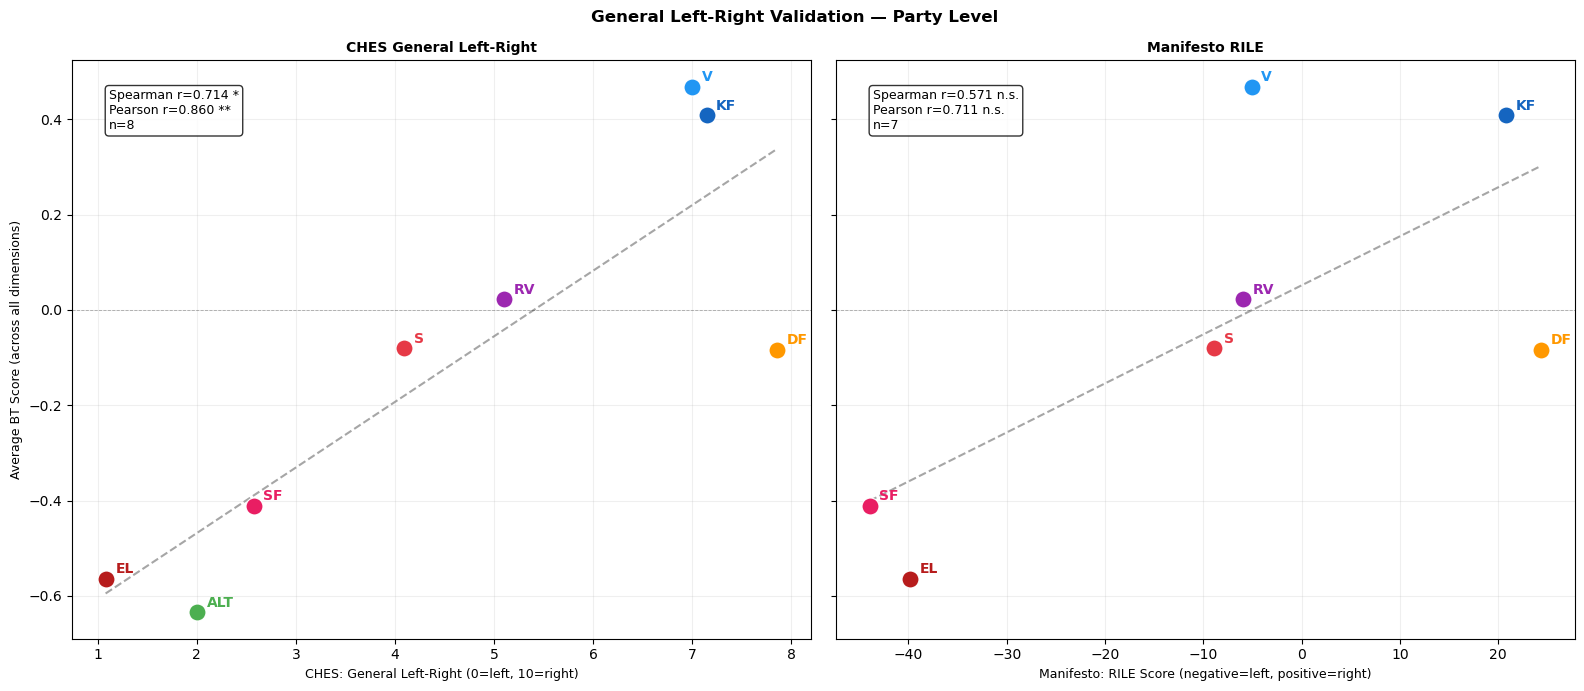

In [98]:
#figure 1: overall LR validation

df_reliable = df_final[
    df_final['reliability_simple'].isin(RELIABILITY_KEEP) &
    df_final['cell_reliable']
].copy()
party_avg_bt = df_reliable.groupby('party', as_index=False)['mean_score'].mean()
party_avg_bt.columns = ['party', 'avg_bt_score']

ches_party = df_ches_dk.groupby('party', as_index=False)['lrgen'].mean()
manifesto_party = (
    df_dk_recent.assign(rile=lambda d: pd.to_numeric(d['rile'], errors='coerce'))
    .groupby('party', as_index=False)['rile'].mean()
)

df_ches_merged = party_avg_bt.merge(ches_party, on='party', how='inner')
df_man_merged  = party_avg_bt.merge(manifesto_party, on='party', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, df, x_col, x_label, title in [
    (axes[0], df_ches_merged, 'lrgen', 'CHES: General Left-Right (0=left, 10=right)', 'CHES General Left-Right'),
    (axes[1], df_man_merged,  'rile',  'Manifesto: RILE Score (negative=left, positive=right)', 'Manifesto RILE'),
]:
    valid = df[[x_col, 'avg_bt_score', 'party']].dropna()
    for _, row in valid.iterrows():
        col = PARTY_COLORS.get(row['party'], 'grey')
        ax.scatter(row[x_col], row['avg_bt_score'], color=col, s=150,
                   zorder=4, edgecolors='white', linewidths=0.8)
        ax.annotate(row['party'], (row[x_col], row['avg_bt_score']),
                    textcoords='offset points', xytext=(7, 4),
                    fontsize=10, color=col, fontweight='bold')
    if len(valid) >= 3:
        m, b, *_ = stats.linregress(valid[x_col], valid['avg_bt_score'])
        xr = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
        ax.plot(xr, m * xr + b, color='grey', linewidth=1.5, linestyle='--', alpha=0.7)
    if len(valid) >= 2:
        rs, ps = stats.spearmanr(valid[x_col], valid['avg_bt_score'])
        rp, pp = pearsonr(valid[x_col], valid['avg_bt_score'])
        sig_s = '***' if ps < 0.001 else '**' if ps < 0.01 else '*' if ps < 0.05 else 'n.s.'
        sig_p = '***' if pp < 0.001 else '**' if pp < 0.01 else '*' if pp < 0.05 else 'n.s.'
        ax.text(0.05, 0.95,
                f"Spearman r={rs:.3f} {sig_s}\nPearson r={rp:.3f} {sig_p}\nn={len(valid)}",
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.3)
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.2)
axes[0].set_ylabel('Average BT Score (across all dimensions)', fontsize=9)
fig.suptitle('General Left-Right Validation — Party Level', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "validation_general_lr.png"), dpi=150, bbox_inches='tight')
plt.show()

## analysis

In [99]:
#analysis dataset

df_analysis = df_final.copy()

print("Analytical dataset:")
for dim_key in DIMENSIONS:
    dim_df = df_analysis[df_analysis['dim_key'] == dim_key]
    print(f"\n{DIM_LABELS[dim_key]}")
    print(f"  Parties: {sorted(dim_df['party'].unique())}")
    print(f"  Years: {sorted(dim_df['year'].unique())}")
    print(f"  Total cells: {len(dim_df)}")
    print(f"  Cell reliable (n>={MIN_SPEECHES}): {dim_df['cell_reliable'].sum()} / {len(dim_df)}")
    print(f"  Full bootstrap  — Confident: {(dim_df['reliability_full']=='confident').sum()} | Usable: {(dim_df['reliability_full']=='usable').sum()} | Uncertain/Unreliable: {(dim_df['reliability_full'].isin(['uncertain','unreliable'])).sum()}")
    print(f"  Simple bootstrap — Confident: {(dim_df['reliability_simple']=='confident').sum()} | Usable: {(dim_df['reliability_simple']=='usable').sum()} | Uncertain/Unreliable: {(dim_df['reliability_simple'].isin(['uncertain','unreliable'])).sum()}")

Analytical dataset:

Labour Market: Welfare Retrenchment
  Parties: ['ALT', 'DF', 'EL', 'KF', 'RV', 'S', 'SF', 'V']
  Years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Total cells: 130
  Cell reliable (n>=5): 114 / 130
  Full bootstrap  — Confident: 129 | Usable: 1 | Uncertain/Unreliable: 0
  Simple bootstrap — Confident: 72 | Usable: 53 | Uncertain/Unreliable: 5

Education: Social Investment
  Parties: ['ALT', 'DF', 'EL', 'KF', 'RV', 'S', 'SF', 'V']
  Years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Total cells: 130
  Cell reliable (n>=5): 119 / 130
  Full bootstrap  — Confident: 125 | Usable: 5 | Uncertain/Unreliable: 0
  Simple bootstrap — Confident: 32 | Usable: 70 | Uncertain/Unreliable: 28

Pension: Fiscal Sustainability
  Parties: ['DF', 'EL', 'RV', 'S', 'SF', 'V']
  Years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022

In [100]:
#appendix table: speeches per government

#aggregate by party, government, dimension
agg = df_final.groupby(['party', 'government', 'dim_key']).agg(
    speeches=('n_speeches', 'sum'),
).reset_index()

agg['dimension'] = agg['dim_key'].map(DIM_SHORT)
agg['govt_label'] = agg['government'].map(GOVT_SHORT)
agg['govt_order'] = agg['government'].map(
    {g: i for i, g in enumerate(GOVERNMENT_ORDER)}
)

#pivot: one row per party-government, columns per dimension
wide = agg.pivot_table(
    index=['party', 'government', 'govt_label', 'govt_order'],
    columns='dimension',
    values='speeches',
    fill_value=0
).astype(int).reset_index()

dim_cols = ['Labour Market', 'Education', 'Pension', 'Family']
available = [d for d in dim_cols if d in wide.columns]
wide['Total'] = wide[available].sum(axis=1)

party_map = {p: i for i, p in enumerate(PARTY_ORDER)}
wide['party_order'] = wide['party'].map(party_map)
wide = wide.sort_values(['party_order', 'govt_order'])

output = wide[['party', 'govt_label'] + available + ['Total']].copy()
output.rename(columns={'govt_label': 'Government'}, inplace=True)

rows = []
for party in PARTY_ORDER:
    p_data = output[output['party'] == party]
    if p_data.empty:
        continue
    for _, row in p_data.iterrows():
        rows.append(row.to_dict())
    subtotal = {'party': party, 'Government': 'Total'}
    for col in available + ['Total']:
        subtotal[col] = p_data[col].sum()
    rows.append(subtotal)

output_final = pd.DataFrame(rows)

output_final.to_csv(
    os.path.join(ANALYSIS_DIR, "appendix_speeches_by_govt.csv"), index=False
)

print(f"Saved: appendix_speeches_by_govt.csv ({len(output_final)} rows)")
print()
print(output_final.to_string(index=False))

Saved: appendix_speeches_by_govt.csv (61 rows)

party Government  Labour Market  Education  Pension  Family  Total
    S         L1             92         77       33      50    252
    S         T1            130         82       72      66    350
    S         T2             28         22        8      15     73
    S         L2             37         30       21      19    107
    S         L3             85        104       83      51    323
    S         F1            103        110       94     112    419
    S         F2             51         74       64      55    244
    S      Total            526        499      375     368   1768
   EL         L1             28         16       10      18     72
   EL         T1            101         32       42      25    200
   EL         T2             15         14        3      11     43
   EL         L2             22          9       11      21     63
   EL         L3             58         56       46      43    203
   EL         

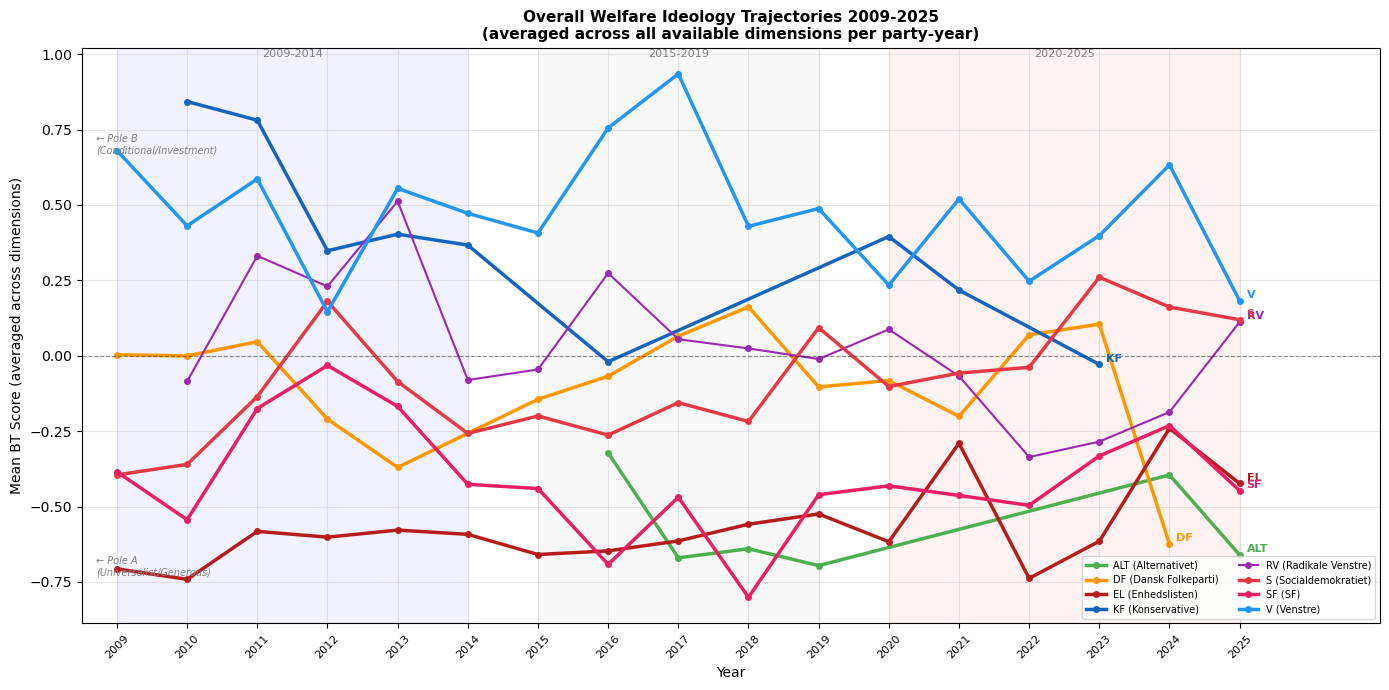

=== AVERAGE BT SCORE ACROSS ALL DIMENSIONS PER PARTY ===

       mean_score  n_obs    bloc
party                           
V           0.469     53   right
KF          0.409     26   right
RV          0.022     47  centre
S          -0.081     66    left
DF         -0.084     51   right
SF         -0.411     53    left
EL         -0.564     64    left
ALT        -0.634     17    left


In [ ]:
#figure 3: ideology trajectories across years

def plot_party_trajectories_aggregated(df_analysis):
    
    df_reliable = df_analysis[
        df_analysis['reliability_simple'].isin(RELIABILITY_KEEP) &
        df_analysis['cell_reliable']
    ].copy()
    
    #aggregate across dimensions per party per year
    df_agg = df_reliable.groupby(['party', 'year']).agg(
        mean_score=('mean_score', 'mean'),
        n_dimensions=('dim_key', 'nunique'),
    ).reset_index()
    
    #only keep party-years with at least 2 dimensions for reliability
    df_agg = df_agg[df_agg['n_dimensions'] >= 2]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for party in sorted(df_agg['party'].unique()):
        party_df = df_agg[df_agg['party'] == party].sort_values('year')
        color = PARTY_COLORS.get(party, 'grey')
        bloc = PARTY_BLOCS.get(party)
        lw = 2.5 if bloc in ['left', 'right'] else 1.5
        
        ax.plot(party_df['year'], party_df['mean_score'],
               color=color, linewidth=lw, marker='o', markersize=4,
               label=f"{party} ({PARTY_LABELS.get(party, party)})")
        
        #label at end of line
        last = party_df.iloc[-1]
        ax.annotate(party,
                   (last['year'], last['mean_score']),
                   textcoords='offset points', xytext=(5, 2),
                   fontsize=8, color=color, fontweight='bold')
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axvspan(2009, 2014, alpha=0.05, color='blue')
    ax.axvspan(2015, 2019, alpha=0.05, color='grey')
    ax.axvspan(2020, 2025, alpha=0.05, color='red')
    
    ax.text(2011.5, ax.get_ylim()[1] * 0.97, '2009-2014',
           ha='center', fontsize=8, color='grey')
    ax.text(2017, ax.get_ylim()[1] * 0.97, '2015-2019',
           ha='center', fontsize=8, color='grey')
    ax.text(2022.5, ax.get_ylim()[1] * 0.97, '2020-2025',
           ha='center', fontsize=8, color='grey')
    
    #bloc annotations on y axis
    ax.text(2008.7, 0.7, '← Pole B\n(Conditional/Investment)',
           fontsize=7, color='grey', style='italic', va='center')
    ax.text(2008.7, -0.7, '← Pole A\n(Universalist/Generous)',
           fontsize=7, color='grey', style='italic', va='center')
    
    ax.set_ylabel('Mean BT Score (averaged across dimensions)', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_title('Overall Welfare Ideology Trajectories 2009-2025\n(averaged across all available dimensions per party-year)',
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2008.5, 2027)
    ax.legend(fontsize=7, ncol=2, loc='lower right',
             bbox_to_anchor=(1.0, 0.0))
    ax.set_xticks(range(2009, 2026))
    ax.set_xticklabels(range(2009, 2026), rotation=45, fontsize=8)  
    
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, "party_trajectories_aggregated.png"),
               dpi=150, bbox_inches='tight')
    plt.show()
    
    #print summary table
    print("AVERAGE BT SCORE ACROSS ALL DIMENSIONS PER PARTY\n")
    party_overall = df_reliable.groupby('party').agg(
        mean_score=('mean_score', 'mean'),
        n_obs=('mean_score', 'count'),
    ).round(3).sort_values('mean_score', ascending=False)
    party_overall['bloc'] = party_overall.index.map(PARTY_BLOCS)
    print(party_overall.to_string())

plot_party_trajectories_aggregated(df_analysis)

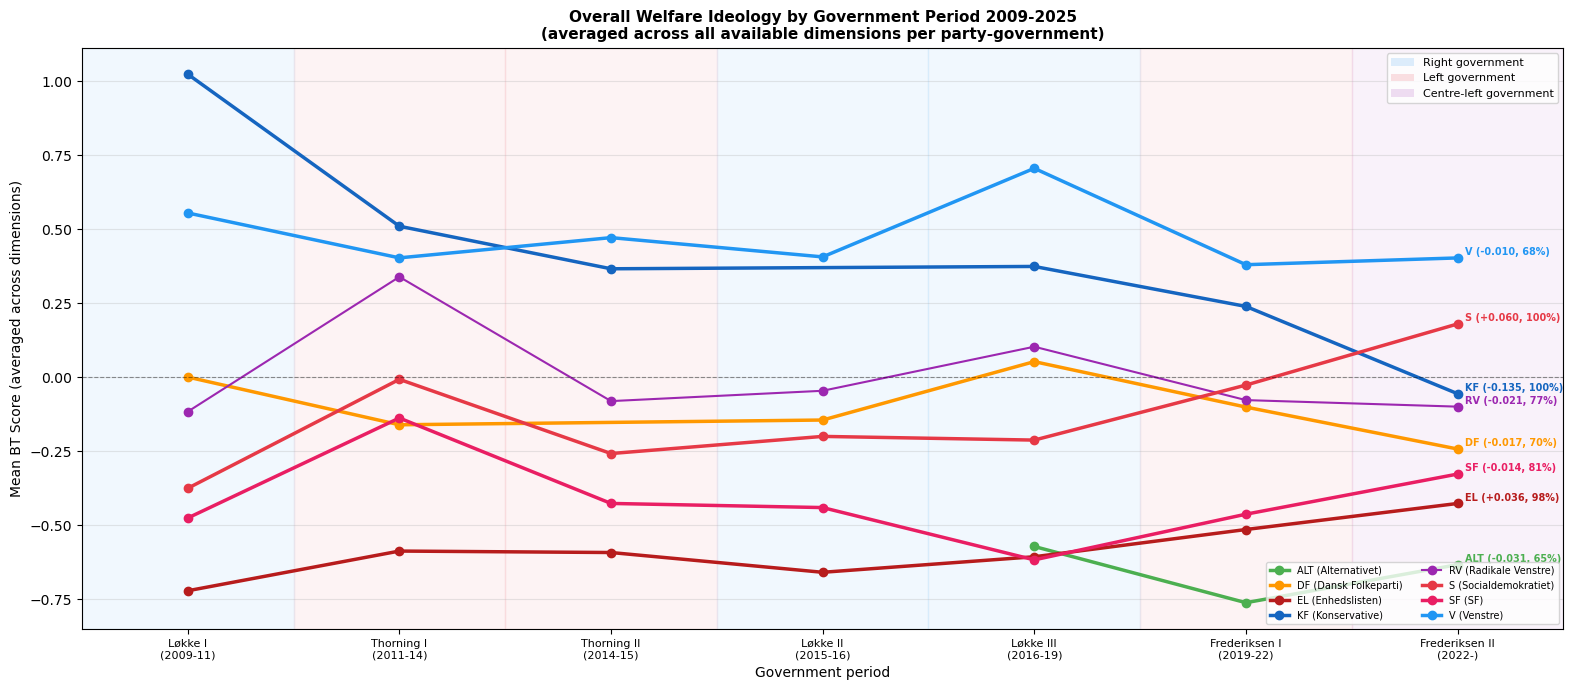


=== OVERALL SLOPES (AVERAGED ACROSS DIMENSIONS, BOOTSTRAP CONFIDENCE) ===

Party     Slope % same dir               95% CI Direction           
S      +0.0598       100%   [+0.0331, +0.0856] → Competition State 
EL     +0.0363        98%   [+0.0010, +0.0731] → Competition State 
V      -0.0096        68%   [-0.0486, +0.0304] → Universalist      
SF     -0.0141        81%   [-0.0462, +0.0189] → Universalist      
DF     -0.0171        70%   [-0.0831, +0.0580] → Universalist      
RV     -0.0214        77%   [-0.0728, +0.0350] → Universalist      
ALT    -0.0307        65%   [-0.1849, +0.1095] → Universalist      
KF     -0.1348       100%   [-0.1981, -0.0757] → Universalist      

=== AVERAGE BT SCORE PER PARTY PER GOVERNMENT ===

government  Løkke I (2009-2011)  Thorning I (2011-2014)  Thorning II (2014-2015)  Løkke II (2015-2016)  Løkke III (2016-2019)  Frederiksen I (2019-2022)  Frederiksen II (2022-)    bloc
party                                                                     

In [ ]:
#figure 3: trajectories across governments

def plot_party_trajectories_by_government(df_final, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    
    df_reliable = df_final[
        df_final['reliability_simple'].isin(RELIABILITY_KEEP) &
        df_final['cell_reliable']
    ].copy()
    
    #aggregate across dimensions per party per government
    df_agg = df_reliable.groupby(['party', 'government']).agg(
        mean_score=('mean_score', 'mean'),
        n_dimensions=('dim_key', 'nunique'),
        n_speeches=('n_speeches', 'sum'),
    ).reset_index()
    
    #only keep party-government cells with at least 2 dimensions
    df_agg = df_agg[df_agg['n_dimensions'] >= 2]
    
    #order governments chronologically
    df_agg['govt_order'] = df_agg['government'].map(
        {g: i for i, g in enumerate(GOVERNMENT_ORDER)}
    )
    df_agg = df_agg.sort_values('govt_order')
    
    #bootstrap slopes per party    
    party_slopes = {}
    
    for party in sorted(df_agg['party'].unique()):
        party_df = df_agg[df_agg['party'] == party].copy()
        
        if len(party_df) < 3:
            continue
        
        x_vals = party_df['govt_order'].values
        y_vals = party_df['mean_score'].values
        
        #point estimate slope
        point_slope, _, _, _, _ = stats.linregress(x_vals, y_vals)
        
        #get the underlying dimension-level data for this party
        party_dim = df_reliable[df_reliable['party'] == party].copy()
        party_dim['govt_order'] = party_dim['government'].map(
            {g: i for i, g in enumerate(GOVERNMENT_ORDER)}
        )
        
        #bootstrap: resample speeches within each party-govt-dimension cell
        boot_slopes = []
        for _ in range(n_bootstrap):
            #resample dimension-level scores within each government period
            boot_rows = []
            for govt in party_df['government'].values:
                govt_data = party_dim[party_dim['government'] == govt]
                if len(govt_data) == 0:
                    continue
                #resample dimensions with replacement
                boot_sample = govt_data.sample(n=len(govt_data), replace=True)
                boot_mean = boot_sample['mean_score'].mean()
                boot_order = govt_data['govt_order'].iloc[0]
                boot_rows.append({'govt_order': boot_order, 'mean_score': boot_mean})
            
            if len(boot_rows) < 3:
                continue
            
            boot_df = pd.DataFrame(boot_rows)
            b_slope, _, _, _, _ = stats.linregress(
                boot_df['govt_order'], boot_df['mean_score']
            )
            boot_slopes.append(b_slope)
        
        boot_slopes = np.array(boot_slopes)
        
        if len(boot_slopes) == 0:
            continue
        
        #% of bootstrap iterations in same direction as point estimate
        if point_slope > 0:
            pct_same = (boot_slopes > 0).mean() * 100
        else:
            pct_same = (boot_slopes < 0).mean() * 100
        
        #CI from bootstrap
        ci_lower = np.percentile(boot_slopes, 2.5)
        ci_upper = np.percentile(boot_slopes, 97.5)
        
        party_slopes[party] = {
            'slope': point_slope,
            'pct_same_direction': round(pct_same, 1),
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
        }
    
    #plot
    fig, ax = plt.subplots(figsize=(16, 7))
    
    for party in sorted(df_agg['party'].unique()):
        party_df = df_agg[df_agg['party'] == party].copy()
        color = PARTY_COLORS.get(party, 'grey')
        bloc = PARTY_BLOCS.get(party)
        lw = 2.5 if bloc in ['left', 'right'] else 1.5
        
        x_vals = party_df['govt_order'].values
        y_vals = party_df['mean_score'].values
        
        ax.plot(x_vals, y_vals,
               color=color, linewidth=lw, marker='o', markersize=6,
               label=f"{party} ({PARTY_LABELS.get(party, party)})")
        
        #label at last point with slope and bootstrap confidence
        if len(party_df) > 0:
            last = party_df.iloc[-1]
            if party in party_slopes:
                s = party_slopes[party]['slope']
                pct = party_slopes[party]['pct_same_direction']
                label_text = f"{party} ({s:+.3f}, {pct:.0f}%)"
            else:
                label_text = party
            ax.annotate(label_text,
                       (last['govt_order'], last['mean_score']),
                       textcoords='offset points', xytext=(5, 2),
                       fontsize=7, color=color, fontweight='bold')
    
    #shade by government bloc
    govt_colors = {
        'right':        '#2196F3',
        'left':         '#E63946',
        'centre-left':  '#9C27B0',
    }
    
    for i, govt in enumerate(GOVERNMENT_ORDER):
        bloc = GOVERNMENT_BLOC.get(govt)
        color = govt_colors.get(bloc, 'grey')
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.06, color=color)
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    
    #x axis labels
    ax.set_xticks(range(len(GOVERNMENT_ORDER)))
    short_labels = [
        'Løkke I\n(2009-11)',
        'Thorning I\n(2011-14)',
        'Thorning II\n(2014-15)',
        'Løkke II\n(2015-16)',
        'Løkke III\n(2016-19)',
        'Frederiksen I\n(2019-22)',
        'Frederiksen II\n(2022-)',
    ]
    ax.set_xticklabels(short_labels, fontsize=8)
    
    #bloc legend for shading
    from matplotlib.patches import Patch
    shade_legend = [
        Patch(facecolor=govt_colors['right'],       alpha=0.15, label='Right government'),
        Patch(facecolor=govt_colors['left'],         alpha=0.15, label='Left government'),
        Patch(facecolor=govt_colors['centre-left'],  alpha=0.15, label='Centre-left government'),
    ]
    
    ax.set_ylabel('Mean BT Score (averaged across dimensions)', fontsize=10)
    ax.set_xlabel('Government period')
    ax.set_title('Overall Welfare Ideology by Government Period 2009-2025\n'
                '(averaged across all available dimensions per party-government)',
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(-0.5, len(GOVERNMENT_ORDER) - 0.5)
    
    #two legends
    party_legend = ax.legend(fontsize=7, ncol=2, loc='lower right',
                            bbox_to_anchor=(1.0, 0.0))
    ax.add_artist(party_legend)
    ax.legend(handles=shade_legend, fontsize=8, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, "party_trajectories_by_government.png"),
               dpi=150, bbox_inches='tight')
    plt.show()
    
    #slopes 
    print("\nOVERALL SLOPES (AVERAGED ACROSS DIMENSIONS, BOOTSTRAP CONFIDENCE)\n")
    print(f"{'Party':<6} {'Slope':>8} {'% same dir':>10} {'95% CI':>20} {'Direction':<20}")
    
    for party in sorted(party_slopes.keys(), key=lambda p: party_slopes[p]['slope'], reverse=True):
        s = party_slopes[party]
        if s['slope'] > 0.005:
            direction = "→ Competition State"
        elif s['slope'] < -0.005:
            direction = "→ Universalist"
        else:
            direction = "≈ Stable"
        ci_str = f"[{s['ci_lower']:+.4f}, {s['ci_upper']:+.4f}]"
        print(f"{party:<6} {s['slope']:>+7.4f} {s['pct_same_direction']:>9.0f}% "
              f"{ci_str:>20} {direction:<20}")
    
    #scores
    print("\nAVERAGE BT SCORE PER PARTY PER GOVERNMENT\n")
    pivot = df_agg.pivot_table(
        index='party', columns='government', values='mean_score'
    ).round(3)
    cols = [g for g in GOVERNMENT_ORDER if g in pivot.columns]
    pivot = pivot[cols]
    pivot['bloc'] = pivot.index.map(PARTY_BLOCS)
    print(pivot.to_string())

plot_party_trajectories_by_government(df_final)

## dimension analysis

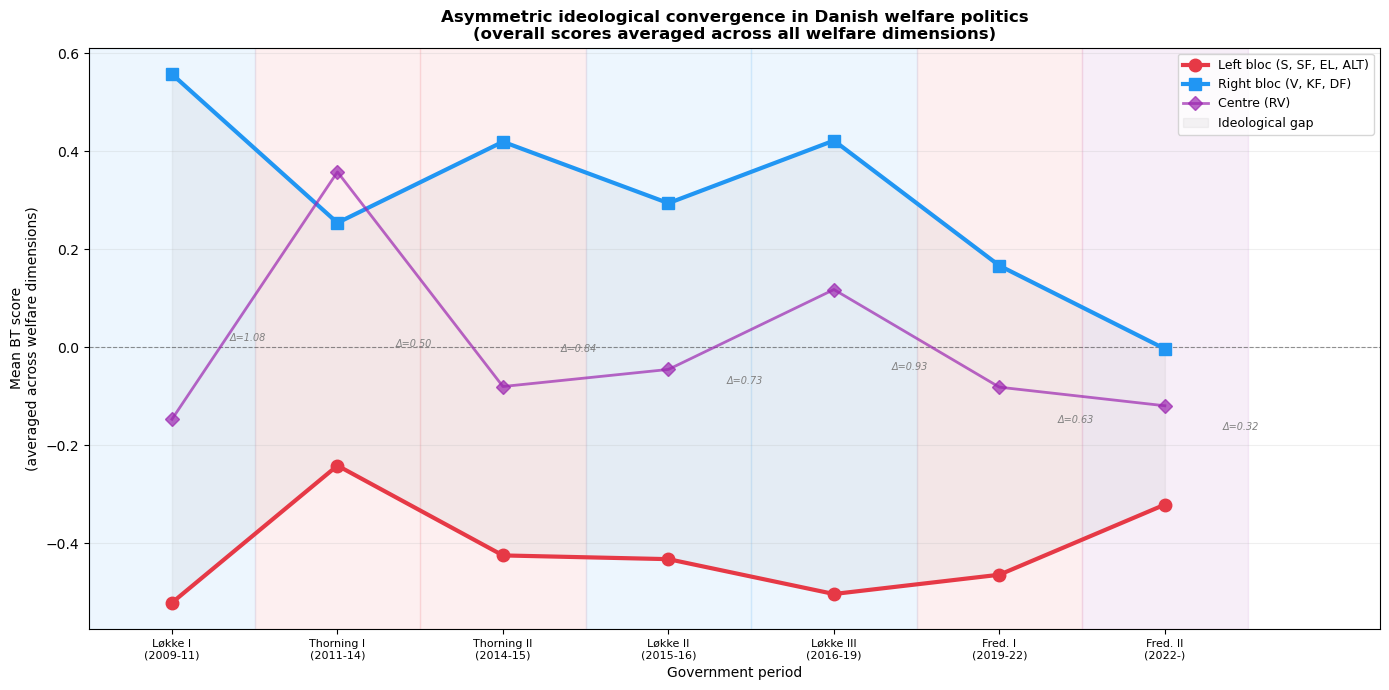


--- BLOC GAP SUMMARY ---
Government                    Left    Right   Centre      Gap
Løkke I (2009-2011)         -0.522   +0.558   -0.147    1.079
Thorning I (2011-2014)      -0.242   +0.254   +0.358    0.496
Thorning II (2014-2015)     -0.425   +0.420   -0.080    0.845
Løkke II (2015-2016)        -0.433   +0.294   -0.045    0.727
Løkke III (2016-2019)       -0.504   +0.422   +0.118    0.926
Frederiksen I (2019-2022)   -0.465   +0.166   -0.082    0.631
Frederiksen II (2022-)      -0.322   -0.003   -0.120    0.318


In [ ]:
#figure 2: bloc convergence across dimensions

def plot_bloc_convergence_govt(df_analysis):
    
    df_reliable = df_analysis[
        df_analysis['reliability_simple'].isin(RELIABILITY_KEEP) &
        df_analysis['cell_reliable']
    ].copy()

    df_reliable['bloc'] = df_reliable['party'].map(PARTY_BLOCS)
    df_reliable = df_reliable.dropna(subset=['bloc'])
    
    #compute overall score per party-year (average across dimensions)
    party_year_overall = df_reliable.groupby(['party', 'year', 'bloc', 'government']).agg(
        mean_score=('mean_score', 'mean'),
    ).reset_index()
    
    #aggregate to government period by bloc
    party_govt = party_year_overall.groupby(['party', 'government', 'bloc']).agg(
        mean_score=('mean_score', 'mean'),
    ).reset_index()
    
    bloc_govt = party_govt.groupby(['government', 'bloc']).agg(
        mean_score=('mean_score', 'mean'),
        n_parties=('party', 'nunique'),
    ).reset_index()
    
    #order governments
    bloc_govt['govt_order'] = bloc_govt['government'].map(
        {g: i for i, g in enumerate(GOVERNMENT_ORDER)}
    )
    bloc_govt = bloc_govt.sort_values('govt_order')
    
    #also compute the gap
    gap_data = []
    for govt in GOVERNMENT_ORDER:
        govt_df = bloc_govt[bloc_govt['government'] == govt]
        left = govt_df[govt_df['bloc'] == 'left']['mean_score'].values
        right = govt_df[govt_df['bloc'] == 'right']['mean_score'].values
        centre = govt_df[govt_df['bloc'] == 'centre']['mean_score'].values
        order = govt_df['govt_order'].iloc[0] if len(govt_df) > 0 else None
        if len(left) > 0 and len(right) > 0 and order is not None:
            gap_data.append({
                'government': govt,
                'govt_order': order,
                'left_mean': left[0],
                'right_mean': right[0],
                'centre_mean': centre[0] if len(centre) > 0 else np.nan,
                'gap': right[0] - left[0],
            })
    df_gap = pd.DataFrame(gap_data)
    
    #plot
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for i, govt in enumerate(GOVERNMENT_ORDER):
        bloc = GOVERNMENT_BLOC.get(govt)
        color = GOVT_COLORS_SHADE.get(bloc, 'grey')
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.08, color=color)
    
    left_df = df_gap[['govt_order', 'left_mean']].dropna()
    ax.plot(left_df['govt_order'], left_df['left_mean'],
           color='#E63946', linewidth=3, marker='o', markersize=9,
           label='Left bloc (S, SF, EL, ALT)', zorder=4)
    
    right_df = df_gap[['govt_order', 'right_mean']].dropna()
    ax.plot(right_df['govt_order'], right_df['right_mean'],
           color='#2196F3', linewidth=3, marker='s', markersize=9,
           label='Right bloc (V, KF, DF)', zorder=4)
    
    centre_df = df_gap[['govt_order', 'centre_mean']].dropna()
    if len(centre_df) > 0:
        ax.plot(centre_df['govt_order'], centre_df['centre_mean'],
               color='#9C27B0', linewidth=2, marker='D', markersize=7,
               label='Centre (RV)', zorder=4, alpha=0.7)
    
    ax.fill_between(df_gap['govt_order'], df_gap['left_mean'], df_gap['right_mean'],
                   alpha=0.08, color='grey', label='Ideological gap')
    
    for _, row in df_gap.iterrows():
        mid_y = (row['left_mean'] + row['right_mean']) / 2
        ax.text(row['govt_order'] + 0.35, mid_y,
               f"Δ={row['gap']:.2f}",
               fontsize=7, color='grey', va='center', ha='left',
               fontstyle='italic')
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    
    short_labels = [
        'Løkke I\n(2009-11)',
        'Thorning I\n(2011-14)',
        'Thorning II\n(2014-15)',
        'Løkke II\n(2015-16)',
        'Løkke III\n(2016-19)',
        'Fred. I\n(2019-22)',
        'Fred. II\n(2022-)',
    ]
    ax.set_xticks(range(len(GOVERNMENT_ORDER)))
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.set_xlim(-0.5, len(GOVERNMENT_ORDER) - 0.5 + 0.8)
    
    ax.set_ylabel('Mean BT score\n(averaged across welfare dimensions)', fontsize=10)
    ax.set_xlabel('Government period', fontsize=10)
    ax.set_title('Asymmetric ideological convergence in Danish welfare politics\n'
                '(overall scores averaged across all welfare dimensions)',
                fontsize=12, fontweight='bold')
    
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.2, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, "bloc_convergence_overall.png"),
               dpi=150, bbox_inches='tight')
    plt.show()
    
    #gap summary
    print("\nBLOC GAP SUMMARY")
    print(f"{'Government':<25} {'Left':>8} {'Right':>8} {'Centre':>8} {'Gap':>8}")
    for _, row in df_gap.iterrows():
        centre_str = f"{row['centre_mean']:>+8.3f}" if not np.isnan(row['centre_mean']) else "     —"
        print(f"{row['government']:<25} {row['left_mean']:>+8.3f} {row['right_mean']:>+8.3f} "
              f"{centre_str} {row['gap']:>8.3f}")

plot_bloc_convergence_govt(df_final)

In [104]:
#table 8: bloc gap by government

df_reliable = df_final[
    df_final['reliability_simple'].isin(RELIABILITY_KEEP) &
    df_final['cell_reliable']
].copy()

df_reliable['bloc'] = df_reliable['party'].map(PARTY_BLOCS)

#only left and right for the gap
df_lr = df_reliable[df_reliable['bloc'].isin(['left', 'right'])].copy()

#observed gap per dimension × government
bloc_means = df_lr.groupby(['dim_key', 'government', 'bloc'])['mean_score'].mean().reset_index()
bloc_pivot = bloc_means.pivot_table(index=['dim_key', 'government'], columns='bloc', values='mean_score').reset_index()
bloc_pivot['gap'] = bloc_pivot['right'] - bloc_pivot['left']

gap_table = bloc_pivot.pivot_table(index='dim_key', columns='government', values='gap')
govt_cols = [g for g in GOVERNMENT_ORDER if g in gap_table.columns]
gap_table = gap_table[govt_cols]
gap_table['Change'] = gap_table.iloc[:, -1] - gap_table.iloc[:, 0]

#bootstrap: resample speeches within each bloc
df_speech_lr = df_speech_scores.copy()
df_speech_lr['bloc'] = df_speech_lr['party'].map(PARTY_BLOCS)
df_speech_lr = df_speech_lr[df_speech_lr['bloc'].isin(['left', 'right'])]

rng = np.random.default_rng(SEED)
boot_changes = {dim: [] for dim in DIMENSIONS}

#pre-group speeches for speed
speech_groups = {}
for (dim_key, govt, bloc), grp in df_speech_lr.groupby(['dim_key', 'government', 'bloc']):
    speech_groups[(dim_key, govt, bloc)] = grp['bt_score'].values

first_govt = GOVERNMENT_ORDER[0]
last_govt = GOVERNMENT_ORDER[-1]

for b in range(N_BOOTSTRAP):
    for dim_key in DIMENSIONS:
        gaps = {}
        for govt in [first_govt, last_govt]:
            bloc_means_boot = {}
            for bloc in ['left', 'right']:
                scores = speech_groups.get((dim_key, govt, bloc))
                if scores is None or len(scores) == 0:
                    bloc_means_boot[bloc] = np.nan
                else:
                    sample = rng.choice(scores, size=len(scores), replace=True)
                    bloc_means_boot[bloc] = sample.mean()
            gaps[govt] = bloc_means_boot['right'] - bloc_means_boot['left']
        boot_changes[dim_key].append(gaps[last_govt] - gaps[first_govt])

#compute bootstrap % supporting observed direction
boot_pct = {}
for dim_key in DIMENSIONS:
    observed = gap_table.loc[dim_key, 'Change']
    if pd.isna(observed):
        boot_pct[dim_key] = np.nan
        continue
    changes = np.array(boot_changes[dim_key])
    changes = changes[~np.isnan(changes)]
    if len(changes) == 0:
        boot_pct[dim_key] = np.nan
    elif observed > 0:
        boot_pct[dim_key] = (changes > 0).mean()
    else:
        boot_pct[dim_key] = (changes < 0).mean()

gap_table['Bootstrap %'] = [boot_pct.get(d, np.nan) for d in gap_table.index]

#print the table
print(f"\n{'Dimension':<20}", end="")
for g in govt_cols:
    print(f"{GOVT_SHORT[g]:>8}", end="")
print(f"{'Change':>10}{'Boot %':>10}")

for dim_key in DIMENSIONS:
    if dim_key not in gap_table.index:
        continue
    row = gap_table.loc[dim_key]
    print(f"{DIM_SHORT[dim_key]:<20}", end="")
    for g in govt_cols:
        val = row[g]
        print(f"{val:>+8.3f}" if pd.notna(val) else f"{'—':>8}", end="")
    change = row['Change']
    print(f"{change:>+10.3f}" if pd.notna(change) else f"{'—':>10}", end="")
    pct = row['Bootstrap %']
    print(f"{pct:>9.0%}" if pd.notna(pct) else f"{'—':>10}")


Dimension                 L1      T1      T2      L2      L3      F1      F2    Change    Boot %
Labour Market         +1.260  +0.917  +0.962  +1.000  +1.294  +1.022  +0.857    -0.403     100%
Education             +0.766  +0.335  +1.183  +1.001  +0.778  +0.203  +0.878    +0.113      67%
Pension               +0.775  +0.586       —  +0.662  +0.822  +0.469  -0.187    -0.962     100%
Family                +0.826  -0.087  -0.044  +0.198  +0.200  +0.309  +0.047    -0.779     100%


In [105]:
#table 9: party-level OLS slopes (absolute and relative)

#valid cells from df_final (already has reliability)
valid_mask = (
    df_final['reliability_simple'].isin(RELIABILITY_KEEP) &
    df_final['cell_reliable']
)
for dim_key, exclude in PARTY_EXCLUSIONS.items():
    valid_mask &= ~(
        (df_final['dim_key'] == dim_key) &
        (df_final['party'].isin(exclude))
    )
df_valid = df_final[valid_mask].copy()
valid_cells = set(zip(df_valid['dim_key'], df_valid['party'], df_valid['year']))

def compute_bootstrapped_slopes(df_speeches, valid_cells, relative=False,
                                 n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    
    df = df_speeches.copy()
    df['cell_key'] = list(zip(df['dim_key'], df['party'], df['year']))
    df = df[df['cell_key'].isin(valid_cells)].copy()
    df.drop(columns=['cell_key'], inplace=True)
    
    #pre-group speeches
    groups = {}
    for (dim_key, party, year), group in df.groupby(['dim_key', 'party', 'year']):
        scores = group['bt_score'].values
        if len(scores) >= MIN_SPEECHES_PER_CELL:
            groups[(dim_key, party, year)] = scores
    
    #party-dim combos with >= 5 years
    party_dim_years = defaultdict(list)
    for (dim_key, party, year) in groups.keys():
        party_dim_years[(dim_key, party)].append(year)
    valid_party_dims = {
        k: sorted(v) for k, v in party_dim_years.items() if len(v) >= 5
    }
    
    #point estimates
    point_slopes = {}
    for (dim_key, party), years in valid_party_dims.items():
        year_means = [(y, np.mean(groups[(dim_key, party, y)]))
                      for y in years if (dim_key, party, y) in groups]
        if len(year_means) < 5:
            continue
        years_arr = np.array([m[0] for m in year_means])
        means_arr = np.array([m[1] for m in year_means])
        if relative:
            for i, y in enumerate(years_arr):
                sys_scores = [np.mean(groups[(dk, p, yr)])
                              for (dk, p, yr) in groups if dk == dim_key and yr == y]
                if sys_scores:
                    means_arr[i] -= np.mean(sys_scores)
        slope, intercept, r, p, se = stats.linregress(years_arr, means_arr)
        point_slopes[(dim_key, party)] = {'slope': slope, 'p_naive': p, 'n_years': len(year_means)}
    
    #bootstrap
    boot_slopes = defaultdict(list)
    for iteration in range(n_bootstrap):
        boot_means = {}
        for (dim_key, party, year), scores in groups.items():
            resampled = rng.choice(scores, size=len(scores), replace=True)
            boot_means[(dim_key, party, year)] = np.mean(resampled)
        if relative:
            sys_means = defaultdict(list)
            for (dim_key, party, year), val in boot_means.items():
                sys_means[(dim_key, year)].append(val)
            sys_means = {k: np.mean(v) for k, v in sys_means.items()}
            boot_means = {k: v - sys_means[(k[0], k[2])] for k, v in boot_means.items()}
        for (dim_key, party), years in valid_party_dims.items():
            year_means = [(y, boot_means[(dim_key, party, y)])
                          for y in years if (dim_key, party, y) in boot_means]
            if len(year_means) < 5:
                continue
            years_arr = np.array([m[0] for m in year_means])
            means_arr = np.array([m[1] for m in year_means])
            slope, _, _, _, _ = stats.linregress(years_arr, means_arr)
            boot_slopes[(dim_key, party)].append(slope)
    
    #assemble results
    results = []
    for (dim_key, party), slopes_list in boot_slopes.items():
        if len(slopes_list) < 100:
            continue
        point = point_slopes.get((dim_key, party), {})
        ci_lower = np.percentile(slopes_list, 2.5)
        ci_upper = np.percentile(slopes_list, 97.5)
        ci_excludes_zero = (ci_lower > 0) or (ci_upper < 0)
        point_slope = point.get('slope', 0)
        pct = np.mean(np.array(slopes_list) > 0) * 100 if point_slope > 0 else (
              np.mean(np.array(slopes_list) < 0) * 100 if point_slope < 0 else 50.0)
        results.append({
            'dim_key': dim_key, 'party': party,
            'slope': round(point.get('slope', np.nan), 5),
            'ci_excludes_zero': ci_excludes_zero,
            'pct_same_sign': round(pct, 1),
            'n_years': point.get('n_years', 0),
        })
    return pd.DataFrame(results).sort_values(['dim_key', 'party']).reset_index(drop=True)

df_slopes_abs = compute_bootstrapped_slopes(df_speech_scores, valid_cells, relative=False)
df_slopes_rel = compute_bootstrapped_slopes(df_speech_scores, valid_cells, relative=True)

#merge abs + rel
df_slopes = df_slopes_abs[['dim_key', 'party', 'slope', 'ci_excludes_zero', 'pct_same_sign']].merge(
    df_slopes_rel[['dim_key', 'party', 'slope', 'ci_excludes_zero', 'pct_same_sign']],
    on=['dim_key', 'party'], suffixes=('_abs', '_rel')
)

#print table
dim_cols = [d for d in DIMENSIONS]

print(f"\n{'Party':<6}", end="")
for d in dim_cols:
    print(f"{DIM_SHORT[d]:>28}", end="")
print()
print(f"{'':>6}", end="")
for _ in dim_cols:
    print(f"{'Abs.':>14}{'Rel.':>14}", end="")
print()

for party in PARTY_ORDER:
    print(f"{party:<6}", end="")
    for dim_key in dim_cols:
        row = df_slopes[(df_slopes['party'] == party) & (df_slopes['dim_key'] == dim_key)]
        if len(row) == 0:
            print(f"{'—':>14}{'—':>14}", end="")
        else:
            r = row.iloc[0]
            star_abs = '*' if r['ci_excludes_zero_abs'] else ''
            star_rel = '*' if r['ci_excludes_zero_rel'] else ''
            abs_str = f"{r['slope_abs']:+.3f}{star_abs} ({r['pct_same_sign_abs']:.0f})"
            rel_str = f"{r['slope_rel']:+.3f}{star_rel} ({r['pct_same_sign_rel']:.0f})"
            print(f"{abs_str:>14}{rel_str:>14}", end="")
    print()


Party                Labour Market                   Education                     Pension                      Family
                Abs.          Rel.          Abs.          Rel.          Abs.          Rel.          Abs.          Rel.
S      +0.044* (100) +0.068* (100)   +0.004 (70)   +0.011 (92) +0.029* (100) +0.029* (100) +0.028* (100)  +0.023* (99)
EL      -0.014* (98)   +0.010 (92) +0.048* (100) +0.053* (100) +0.023* (100)   +0.008 (81)   +0.015 (97)   +0.010 (90)
ALT      -0.029 (92)   -0.014 (75)             —             —             —             —   -0.010 (65)   -0.012 (74)
SF       -0.018 (89)   +0.005 (62)   -0.018 (96)   -0.014 (93)  +0.026* (99) +0.031* (100)   -0.003 (63)   -0.007 (79)
RV      -0.049* (98)   -0.027 (93)  -0.033* (98)   -0.021 (92)   -0.030 (94)   -0.019 (87)   +0.009 (73)   +0.003 (60)
DF       +0.000 (52)   +0.026 (93) +0.062* (100) +0.062* (100)  -0.027* (99) -0.027* (100)  -0.022* (98) -0.027* (100)
KF      -0.037* (99)   -0.018 (88) -0.081* (100

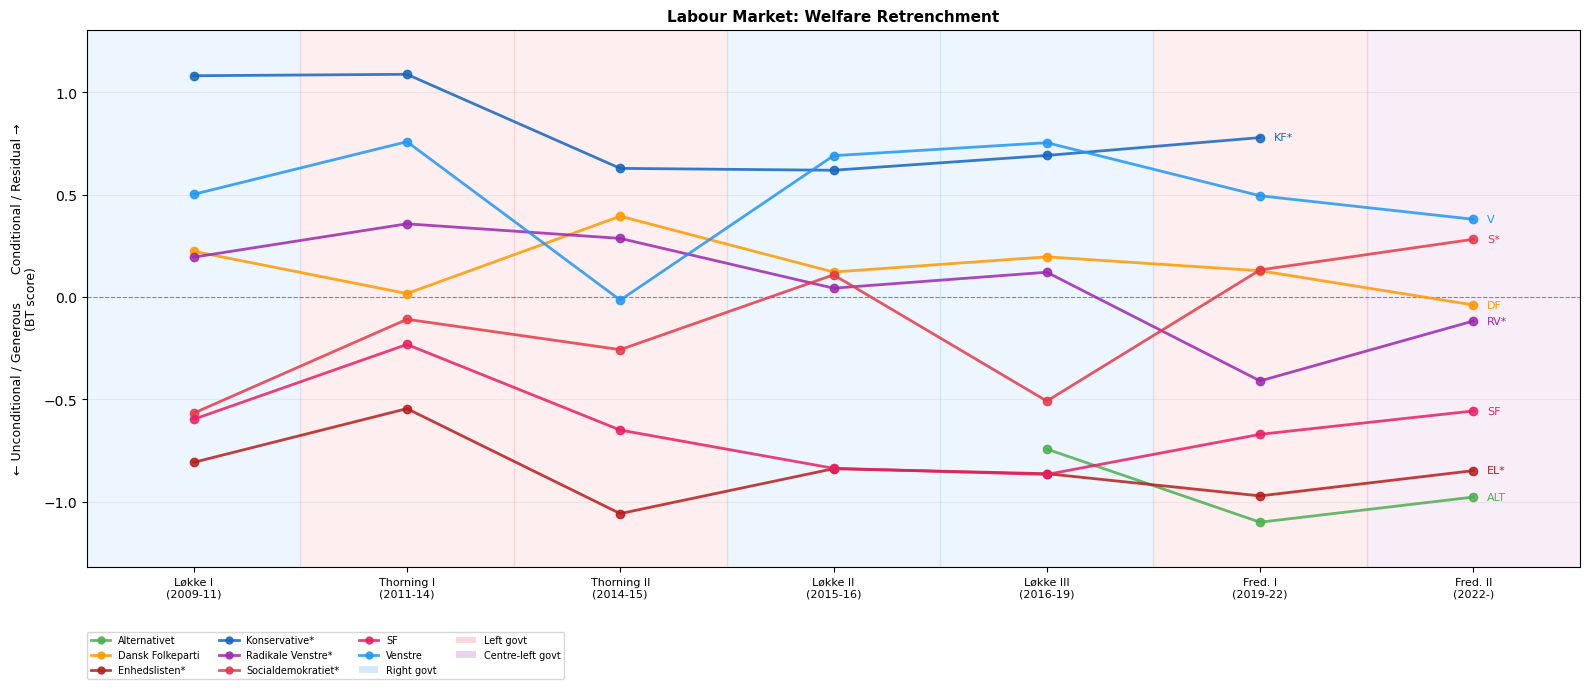

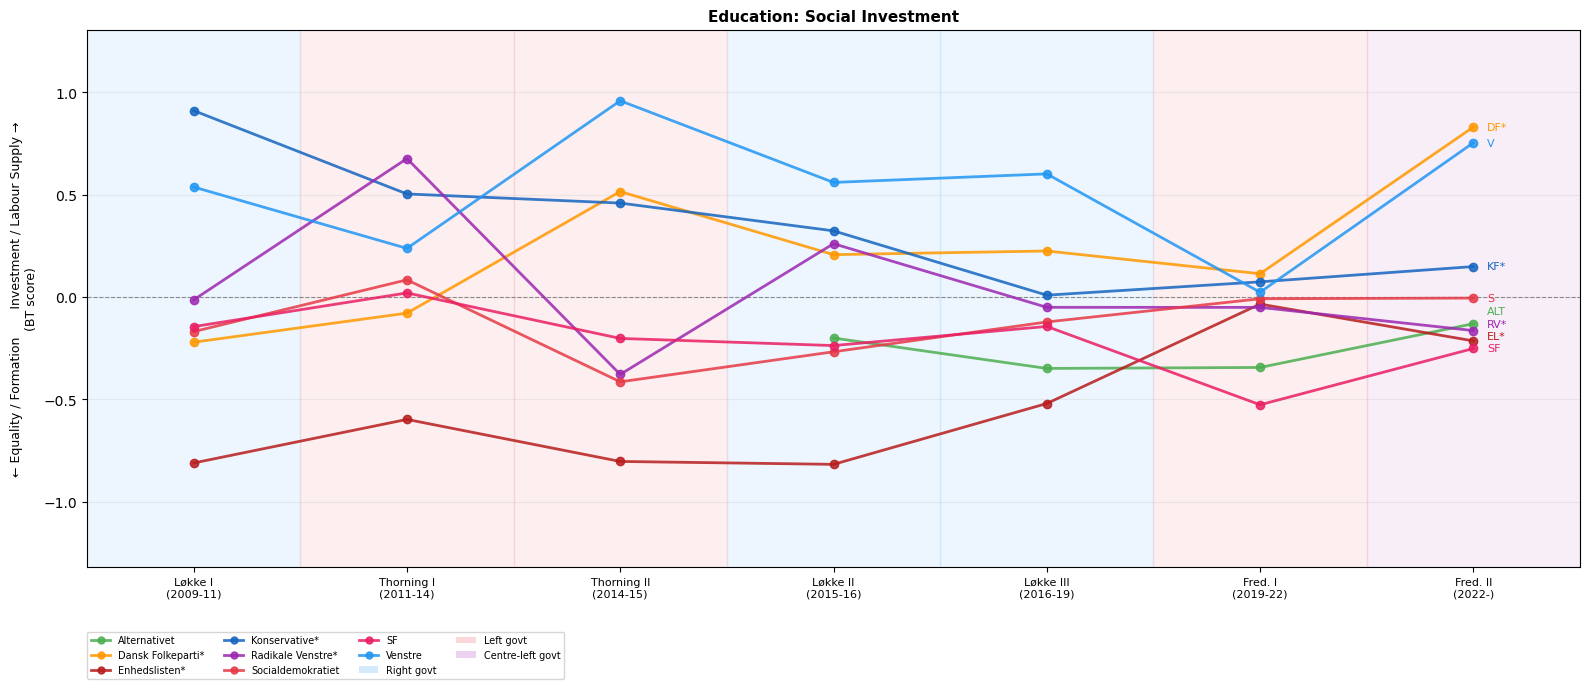

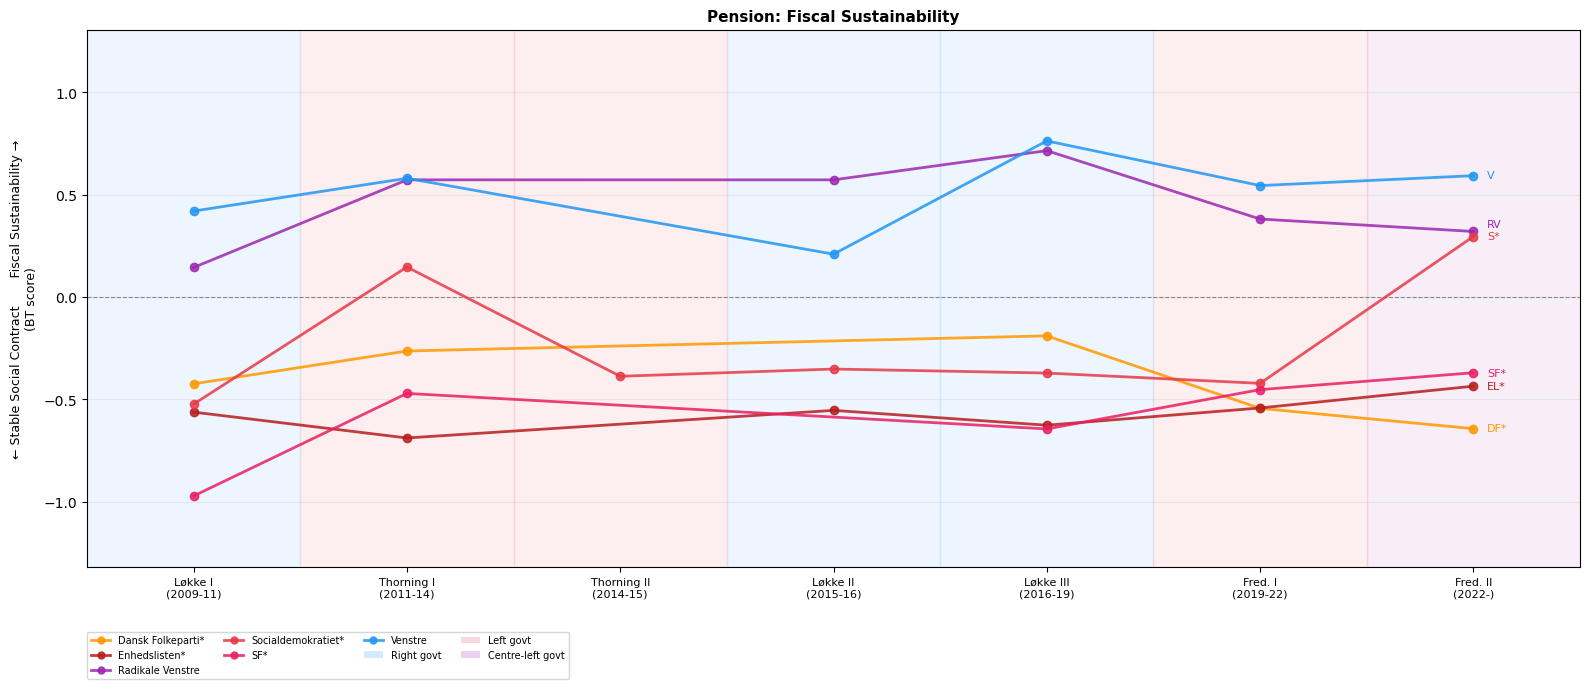

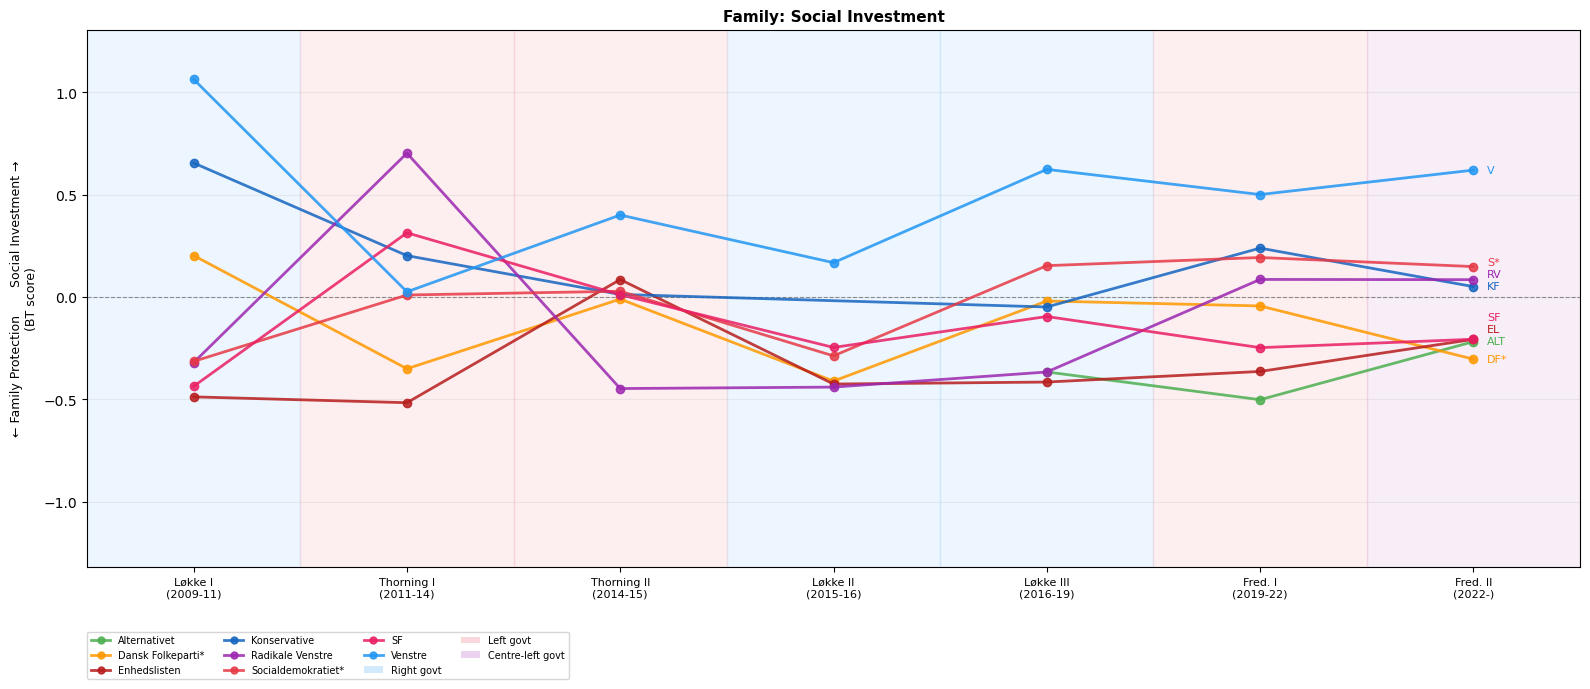

In [120]:
#figures 4-7: trajectory plots per dimension

def plot_trajectories_govt(df_final, df_slopes_abs, dimensions=DIMENSIONS):
    df_reliable = df_final[df_final['cell_reliable']].copy()
    
    #first pass: find global y-axis range across all dimensions
    y_min_global = float('inf')
    y_max_global = float('-inf')
    
    for dim_key in dimensions:
        dim_df = df_reliable[df_reliable['dim_key'] == dim_key]
        dim_govt = dim_df.groupby(['party', 'government']).agg(
            mean_score=('mean_score', 'mean'),
        ).reset_index()
        
        if len(dim_govt) > 0:
            y_min_global = min(y_min_global, dim_govt['mean_score'].min())
            y_max_global = max(y_max_global, dim_govt['mean_score'].max())
    
    #add padding
    y_padding = (y_max_global - y_min_global) * 0.10
    y_min_global -= y_padding
    y_max_global += y_padding
    
    #second pass: plot each dimension
    for dim_key in dimensions:
        dim_df = df_reliable[df_reliable['dim_key'] == dim_key]
        parties = sorted(dim_df['party'].unique())
        
        #get significant parties for this dimension
        dim_slopes = df_slopes_abs[df_slopes_abs['dim_key'] == dim_key]
        sig_parties = set(
            dim_slopes[dim_slopes['ci_excludes_zero']]['party'].values
        )
        
        #aggregate to government period
        dim_govt = dim_df.groupby(['party', 'government']).agg(
            mean_score=('mean_score', 'mean'),
            n_speeches=('n_speeches', 'sum'),
        ).reset_index()
        
        dim_govt['govt_order'] = dim_govt['government'].map(
            {g: i for i, g in enumerate(GOVERNMENT_ORDER)}
        )
        dim_govt = dim_govt.sort_values('govt_order')
        
        fig, ax = plt.subplots(figsize=(16, 7))
        
        #government background shading
        for i, govt in enumerate(GOVERNMENT_ORDER):
            bloc = GOVERNMENT_BLOC.get(govt)
            color = GOVT_COLORS_SHADE.get(bloc, 'grey')
            ax.axvspan(i - 0.5, i + 0.5, alpha=0.08, color=color)
        
        #track end positions for label offset
        end_positions = []
        
        #party trajectories — all equal visual weight
        for party in parties:
            party_df = dim_govt[dim_govt['party'] == party].copy()
            if len(party_df) == 0:
                continue
            
            color = PARTY_COLORS.get(party, 'grey')
            x_vals = party_df['govt_order'].values
            y_vals = party_df['mean_score'].values
            
            ax.plot(x_vals, y_vals,
                   color=color,
                   linewidth=2,
                   alpha=0.85,
                   marker='o',
                   markersize=6,
                   label=PARTY_LABELS.get(party, party),
                   zorder=3)
            
            #end label — star for significant, plain for others
            if len(party_df) > 0:
                last_x = party_df['govt_order'].iloc[-1]
                last_y = party_df['mean_score'].iloc[-1]
                is_sig = party in sig_parties
                label_text = f"{party}*" if is_sig else party
                end_positions.append((last_x, last_y, label_text, color))
        
        #smart label placement — offset overlapping labels
        end_positions.sort(key=lambda x: x[1])
        min_gap = 0.06
        
        adjusted_positions = []
        for i, (x, y, text, color) in enumerate(end_positions):
            adjusted_y = y
            for _, prev_y, _, _ in adjusted_positions:
                if abs(adjusted_y - prev_y) < min_gap:
                    adjusted_y = prev_y + min_gap
            adjusted_positions.append((x, adjusted_y, text, color))
        
        for x, y, text, color in adjusted_positions:
            ax.annotate(text,
                       (x, y),
                       textcoords='offset points', xytext=(10, 0),
                       fontsize=8, color=color, fontweight='normal',
                       va='center')
        
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
        
        #shared y-axis
        ax.set_ylim(y_min_global, y_max_global)
        
        short_labels = [
            'Løkke I\n(2009-11)',
            'Thorning I\n(2011-14)',
            'Thorning II\n(2014-15)',
            'Løkke II\n(2015-16)',
            'Løkke III\n(2016-19)',
            'Fred. I\n(2019-22)',
            'Fred. II\n(2022-)',
        ]
        ax.set_xticks(range(len(GOVERNMENT_ORDER)))
        ax.set_xticklabels(short_labels, fontsize=8)
        ax.set_xlim(-0.5, len(GOVERNMENT_ORDER) - 0.5)
        
        if dim_key in DIM_POLE_LABELS:
            poles = DIM_POLE_LABELS[dim_key]
            ax.set_ylabel(f"← {poles['a']}       {poles['b']} →\n(BT score)", fontsize=9)
        else:
            ax.set_ylabel('Mean BT score', fontsize=9)
        
        ax.set_title(f"{DIM_LABELS[dim_key]}", fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.2, axis='y')
        
        party_handles = [
            Line2D([0], [0], color=PARTY_COLORS.get(p, 'grey'),
                   linewidth=2, alpha=0.85, marker='o', markersize=5,
                   label=f"{PARTY_LABELS.get(p, p)}{'*' if p in sig_parties else ''}")
            for p in parties
        ]
        
        govt_handles = [
            Patch(facecolor=GOVT_COLORS_SHADE['right'],      alpha=0.2, label='Right govt'),
            Patch(facecolor=GOVT_COLORS_SHADE['left'],        alpha=0.2, label='Left govt'),
            Patch(facecolor=GOVT_COLORS_SHADE['centre-left'], alpha=0.2, label='Centre-left govt'),
        ]
        
        ax.legend(handles=party_handles + govt_handles,
                 fontsize=7, ncol=4, loc='upper left',
                 bbox_to_anchor=(0, -0.12), borderaxespad=0)
        
        plt.tight_layout()
        plt.savefig(os.path.join(ANALYSIS_DIR, f"trajectory_govt_{dim_key}.png"),
                   dpi=150, bbox_inches='tight')
        plt.show()

plot_trajectories_govt(df_final, df_slopes_abs)

## government analysis

In [ ]:
#incumbency analysis: setup (helpers + bootstrap period means)

#helpers
def add_role_column(df):
    if 'role' not in df.columns:
        df = df.copy()
        df['role'] = df.apply(
            lambda r: assign_role(r['government'], r['party']), axis=1
        )
    return df

def get_reliable(df):
    df = add_role_column(df)
    return df[
        df['reliability_simple'].isin(RELIABILITY_KEEP) &
        df['cell_reliable']
    ].copy()

COALITION_TYPE = {
    'Løkke I (2009-2011)':       'Right coalition (DF support)',
    'Thorning I (2011-2014)':    'Left single-party (left support)',
    'Thorning II (2014-2015)':   'Left single-party (left support)',
    'Løkke II (2015-2016)':      'Right single-party',
    'Løkke III (2016-2019)':     'Right coalition (DF support)',
    'Frederiksen I (2019-2022)': 'Left single-party (left support)',
    'Frederiksen II (2022-)':    'Grand coalition (S+V)',
}
COALITION_TYPE_ORDER = [
    'Right coalition (DF support)',
    'Right single-party',
    'Left single-party (left support)',
    'Grand coalition (S+V)',
]

#bootstrap
def bootstrap_period_means(df_reliable, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    df = df_reliable.copy()
    df_point = df.groupby(['party', 'dim_key', 'government']).agg(
        mean_score=('mean_score', 'mean'),
        n=('mean_score', 'count'),
    ).reset_index()

    boot_dict = {}
    for (party, dim_key, government), group in df.groupby(
            ['party', 'dim_key', 'government']):
        scores = group['mean_score'].values
        if len(scores) == 0:
            continue
        boot_means = np.array([
            rng.choice(scores, size=len(scores), replace=True).mean()
            for _ in range(n_bootstrap)
        ])
        boot_dict[(party, dim_key, government)] = boot_means
    return df_point, boot_dict

def compute_bootstrapped_movement(df_point, boot_dict):
    govt_order_map = {g: i for i, g in enumerate(GOVERNMENT_ORDER)}
    df_point['govt_order'] = df_point['government'].map(govt_order_map)
    df_point = df_point.sort_values(['party', 'dim_key', 'govt_order'])

    records = []
    for (party, dim_key), group in df_point.groupby(['party', 'dim_key']):
        group = group.sort_values('govt_order')
        for i in range(1, len(group)):
            prev = group.iloc[i - 1]
            curr = group.iloc[i]
            if curr['govt_order'] != prev['govt_order'] + 1:
                continue
            prev_key = (party, dim_key, prev['government'])
            curr_key = (party, dim_key, curr['government'])
            if prev_key not in boot_dict or curr_key not in boot_dict:
                continue
            change = curr['mean_score'] - prev['mean_score']
            boot_changes = boot_dict[curr_key] - boot_dict[prev_key]
            ci_lo = np.percentile(boot_changes, 2.5)
            ci_hi = np.percentile(boot_changes, 97.5)
            significant = (ci_lo > 0) or (ci_hi < 0)
            pct_toward_B = (boot_changes > 0).mean() * 100
            role = assign_role(curr['government'], party)
            records.append({
                'party': party, 'dim_key': dim_key,
                'dimension': DIM_LABELS.get(dim_key, dim_key),
                'government': curr['government'],
                'prev_government': prev['government'],
                'govt_order': curr['govt_order'],
                'role': role,
                'coalition_type': COALITION_TYPE.get(curr['government'], 'Unknown'),
                'score_before': round(prev['mean_score'], 3),
                'score_after': round(curr['mean_score'], 3),
                'change': round(change, 3),
                'abs_change': round(abs(change), 3),
                'ci_lo': round(ci_lo, 3),
                'ci_hi': round(ci_hi, 3),
                'significant': significant,
                'pct_toward_B': round(pct_toward_B, 1),
            })
    return pd.DataFrame(records)

df_rel = get_reliable(df_final)
df_point, boot_dict = bootstrap_period_means(df_rel)
df_movement_boot = compute_bootstrapped_movement(df_point, boot_dict)

running period-mean bootstrap (1000 iterations)...


In [108]:
#tables 11, 12, 13: incumbency, coalition type, S/V convergence

#table 11: direction by government role and dimensions
def table_11_direction_by_role(df_movement_boot, boot_dict, df_point,
                               n_bootstrap=N_BOOTSTRAP):
    govt_order_map = {g: i for i, g in enumerate(GOVERNMENT_ORDER)}
    df_ps = df_point.copy()
    df_ps['govt_order'] = df_ps['government'].map(govt_order_map)

    #build transition structure
    transitions = []
    for (party, dim_key), group in df_ps.groupby(['party', 'dim_key']):
        group = group.sort_values('govt_order')
        for i in range(1, len(group)):
            prev = group.iloc[i - 1]
            curr = group.iloc[i]
            if curr['govt_order'] != prev['govt_order'] + 1:
                continue
            prev_key = (party, dim_key, prev['government'])
            curr_key = (party, dim_key, curr['government'])
            if prev_key not in boot_dict or curr_key not in boot_dict:
                continue
            role = assign_role(curr['government'], party)
            transitions.append({
                'party': party, 'dim_key': dim_key, 'role': role,
                'prev_key': prev_key, 'curr_key': curr_key,
            })

    #bootstrap per (role, dim_key) and aggregate
    role_dim_boot = {}
    role_agg_boot = {}
    for role in ['government', 'support', 'opposition']:
        for dim_key in DIMENSIONS:
            role_dim_boot[(role, dim_key)] = []
        role_agg_boot[role] = []

    for b in range(n_bootstrap):
        counts = {}
        agg_counts = {}
        for role in ['government', 'support', 'opposition']:
            agg_counts[role] = {'pos': 0, 'total': 0}
            for dim_key in DIMENSIONS:
                counts[(role, dim_key)] = {'pos': 0, 'total': 0}

        for t in transitions:
            change = boot_dict[t['curr_key']][b] - boot_dict[t['prev_key']][b]
            key = (t['role'], t['dim_key'])
            counts[key]['total'] += 1
            counts[key]['pos'] += int(change > 0)
            agg_counts[t['role']]['total'] += 1
            agg_counts[t['role']]['pos'] += int(change > 0)

        for role in ['government', 'support', 'opposition']:
            for dim_key in DIMENSIONS:
                key = (role, dim_key)
                if counts[key]['total'] > 0:
                    role_dim_boot[key].append(
                        counts[key]['pos'] / counts[key]['total'] * 100)
                else:
                    role_dim_boot[key].append(np.nan)
            if agg_counts[role]['total'] > 0:
                role_agg_boot[role].append(
                    agg_counts[role]['pos'] / agg_counts[role]['total'] * 100)
            else:
                role_agg_boot[role].append(np.nan)

    #format table

    header_dims = [DIM_SHORT[d] for d in DIMENSIONS]
    print(f"\n{'':>20}", end="")
    for h in header_dims:
        print(f"{h:>18}", end="")
    print(f"{'Aggregate':>18}")

    for role in ['government', 'opposition']:
        role_label = f"{'Govt' if role == 'government' else 'Opp'} % → B"
        print(f"{role_label:<20}", end="")
        for dim_key in DIMENSIONS:
            sub = df_movement_boot[
                (df_movement_boot['role'] == role) &
                (df_movement_boot['dim_key'] == dim_key)
            ]
            obs_pct = (sub['change'] > 0).mean() * 100 if len(sub) > 0 else np.nan
            boot_arr = np.array([x for x in role_dim_boot[(role, dim_key)]
                                 if not np.isnan(x)])
            pct_dir = (boot_arr > 50).mean() * 100 if len(boot_arr) > 0 else np.nan
            if pd.notna(obs_pct):
                print(f"{obs_pct:>8.1f}% ({pct_dir:.0f}%)", end="")
            else:
                print(f"{'—':>18}", end="")
        #aggregate
        agg_sub = df_movement_boot[df_movement_boot['role'] == role]
        agg_obs = (agg_sub['change'] > 0).mean() * 100 if len(agg_sub) > 0 else np.nan
        agg_boot = np.array([x for x in role_agg_boot[role] if not np.isnan(x)])
        agg_pct = (agg_boot > 50).mean() * 100 if len(agg_boot) > 0 else np.nan
        print(f"{agg_obs:>8.1f}% ({agg_pct:.0f}%)")

    #difference row
    print(f"{'Difference':<20}", end="")
    for dim_key in DIMENSIONS:
        govt_sub = df_movement_boot[
            (df_movement_boot['role'] == 'government') &
            (df_movement_boot['dim_key'] == dim_key)
        ]
        opp_sub = df_movement_boot[
            (df_movement_boot['role'] == 'opposition') &
            (df_movement_boot['dim_key'] == dim_key)
        ]
        obs_diff = ((govt_sub['change'] > 0).mean() -
                     (opp_sub['change'] > 0).mean()) * 100
        govt_boot = np.array([x for x in role_dim_boot[('government', dim_key)]
                              if not np.isnan(x)])
        opp_boot = np.array([x for x in role_dim_boot[('opposition', dim_key)]
                             if not np.isnan(x)])
        min_len = min(len(govt_boot), len(opp_boot))
        boot_diff = govt_boot[:min_len] - opp_boot[:min_len]
        pct_dir = (boot_diff > 0).mean() * 100
        print(f"{obs_diff:>+7.1f}pp ({pct_dir:.0f}%)", end="")
    #aggregate difference
    agg_govt = np.array([x for x in role_agg_boot['government'] if not np.isnan(x)])
    agg_opp = np.array([x for x in role_agg_boot['opposition'] if not np.isnan(x)])
    min_len = min(len(agg_govt), len(agg_opp))
    agg_diff_boot = agg_govt[:min_len] - agg_opp[:min_len]
    agg_obs_diff = ((df_movement_boot[df_movement_boot['role'] == 'government']['change'] > 0).mean() -
                    (df_movement_boot[df_movement_boot['role'] == 'opposition']['change'] > 0).mean()) * 100
    agg_pct_dir = (agg_diff_boot > 0).mean() * 100
    print(f"{agg_obs_diff:>+7.1f}pp ({agg_pct_dir:.0f}%)")

    #N rows
    for role in ['government', 'opposition']:
        label = f"N ({'govt' if role == 'government' else 'opp'})"
        print(f"{label:<20}", end="")
        total = 0
        for dim_key in DIMENSIONS:
            n = len(df_movement_boot[
                (df_movement_boot['role'] == role) &
                (df_movement_boot['dim_key'] == dim_key)
            ])
            total += n
            print(f"{n:>18}", end="")
        print(f"{total:>18}")

    return role_dim_boot, role_agg_boot

#table 12: coalition type movement

def table_12_coalition_type(df_movement_boot, n_bootstrap=N_BOOTSTRAP):

    print(f"\n{'Coalition type':<40} {'% toward B':>10} {'Mean |Δ|':>10} {'N':>6}")

    for ct in COALITION_TYPE_ORDER:
        ct_df = df_movement_boot[df_movement_boot['coalition_type'] == ct]
        if len(ct_df) < 3:
            continue
        changes = ct_df['change'].values
        obs_pct_B = (changes > 0).mean() * 100
        obs_mean_abs = np.abs(changes).mean()
        print(f"{ct:<40} {obs_pct_B:>9.1f}% {obs_mean_abs:>10.3f} {len(ct_df):>6}")

#table 13: S vs V convergence under Frederiksen II

def table_13_sv_convergence(df_reliable, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)

    print(f"\n{'Dimension':<18} {'S bef':>7} {'S aft':>7} {'V bef':>7} {'V aft':>7} "
          f"{'Gap bef':>8} {'Gap aft':>8} {'Convergence':>14}")

    results = []
    for dim_key in DIMENSIONS:
        dim_df = df_reliable[df_reliable['dim_key'] == dim_key]
        s_before = dim_df[(dim_df['party'] == 'S') &
                          (dim_df['government'] == 'Frederiksen I (2019-2022)')
                          ]['mean_score'].values
        v_before = dim_df[(dim_df['party'] == 'V') &
                          (dim_df['government'] == 'Frederiksen I (2019-2022)')
                          ]['mean_score'].values
        s_after = dim_df[(dim_df['party'] == 'S') &
                         (dim_df['government'] == 'Frederiksen II (2022-)')
                         ]['mean_score'].values
        v_after = dim_df[(dim_df['party'] == 'V') &
                         (dim_df['government'] == 'Frederiksen II (2022-)')
                         ]['mean_score'].values

        if any(len(x) == 0 for x in [s_before, v_before, s_after, v_after]):
            continue

        gap_before = abs(s_before.mean() - v_before.mean())
        gap_after = abs(s_after.mean() - v_after.mean())
        convergence = gap_before - gap_after

        boot_convergence = []
        for _ in range(n_bootstrap):
            sb = rng.choice(s_before, size=len(s_before), replace=True).mean()
            vb = rng.choice(v_before, size=len(v_before), replace=True).mean()
            sa = rng.choice(s_after, size=len(s_after), replace=True).mean()
            va = rng.choice(v_after, size=len(v_after), replace=True).mean()
            boot_convergence.append(abs(sb - vb) - abs(sa - va))

        boot_convergence = np.array(boot_convergence)
        pct_converging = (boot_convergence > 0).mean() * 100

        results.append({
            'dim_key': dim_key,
            's_before': s_before.mean(), 'v_before': v_before.mean(),
            's_after': s_after.mean(), 'v_after': v_after.mean(),
            'gap_before': gap_before, 'gap_after': gap_after,
            'convergence': convergence, 'pct_converging': pct_converging,
        })

        print(f"{DIM_SHORT[dim_key]:<18} {s_before.mean():>+7.3f} {s_after.mean():>+7.3f} "
              f"{v_before.mean():>+7.3f} {v_after.mean():>+7.3f} "
              f"{gap_before:>8.3f} {gap_after:>8.3f} "
              f"{convergence:>+8.3f} ({pct_converging:.0f}%)")

    return pd.DataFrame(results)

table_11_direction_by_role(df_movement_boot, boot_dict, df_point)
table_12_coalition_type(df_movement_boot)
table_13_sv_convergence(df_rel)


                         Labour Market         Education           Pension            Family         Aggregate
Govt % → B              72.7% (100%)    77.8% (94%)    57.1% (99%)    62.5% (48%)    68.6% (100%)
Opp % → B               47.6% (19%)    45.5% (9%)    45.5% (43%)    47.4% (12%)    46.6% (8%)
Difference            +25.1pp (100%)  +32.3pp (94%)  +11.7pp (89%)  +15.1pp (86%)  +22.0pp (100%)
N (govt)                            11                 9                 7                 8                35
N (opp)                             21                22                11                19                73

Coalition type                           % toward B   Mean |Δ|      N
Right coalition (DF support)                  60.0%      0.187     20
Right single-party                            42.9%      0.228     14
Left single-party (left support)              51.4%      0.277     70
Grand coalition (S+V)                         60.7%      0.219     28

Dimension            S b

,dim_key,s_before,v_before,s_after,v_after,gap_before,gap_after,convergence,pct_converging
0,labour_market_policy__welfare_retrenchment,0.132477,0.494811,0.282245,0.380095,0.362334,0.097850,0.264484,87.1
1,education__social_investment,-0.008456,0.023420,-0.005085,0.828251,0.031876,0.833337,-0.801461,0.0
2,pension__fiscal_sustainability,-0.421890,0.544690,0.295710,0.504220,0.966579,0.208511,0.758069,99.9
3,family__social_investment,0.193163,0.500875,0.148791,0.176203,0.307712,0.027411,0.280301,97.9


Party-dimensions with >=2 years in both govt and opp: 16
Running 1000 bootstrap iterations...
  250/1000
  500/1000
  750/1000
  1000/1000


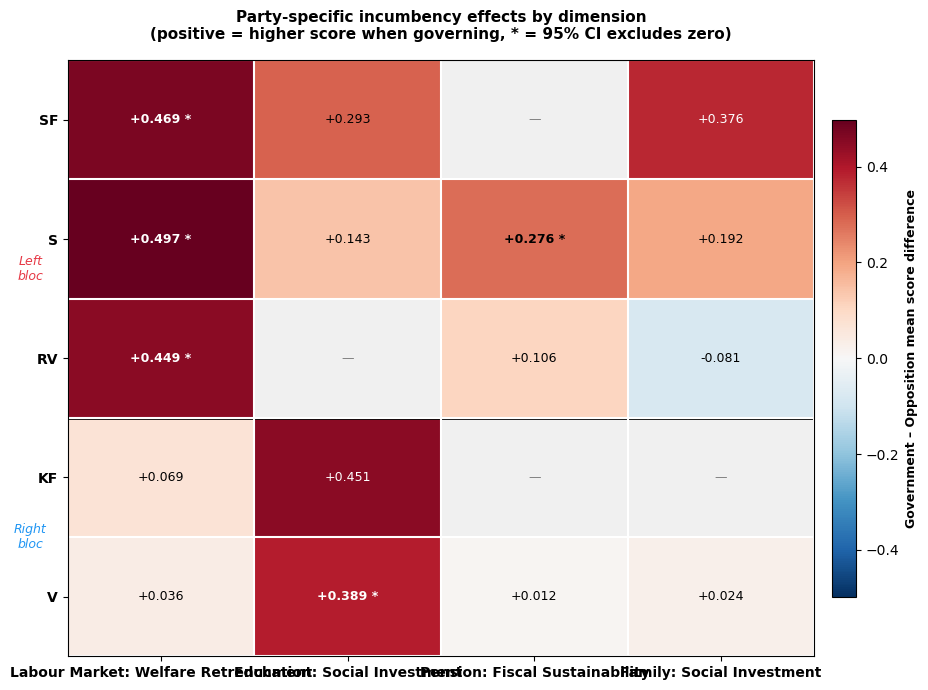

In [109]:
#figure 8: party-specific incumbency (govt vs opposition heatmap)

def bootstrap_govt_opposition_levels(df_speeches, valid_cells,
                                      n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    
    #filter and add government status
    df = df_speeches.copy()
    df['cell_key'] = list(zip(df['dim_key'], df['party'], df['year']))
    df = df[df['cell_key'].isin(valid_cells)].copy()
    df.drop(columns=['cell_key'], inplace=True)
    df['government'] = df['year'].map(GOVERNMENT_PERIODS)
    df['in_government'] = df.apply(
        lambda row: row['party'] in GOVT_PARTIES.get(row['government'], []),
        axis=1
    )
    
    #pre-group speeches
    groups = {}
    for (dim_key, party, year), group in df.groupby(['dim_key', 'party', 'year']):
        scores = group['bt_score'].values
        in_govt = group['in_government'].iloc[0]
        if len(scores) >= MIN_SPEECHES_PER_CELL:
            groups[(dim_key, party, year)] = {
                'scores': scores,
                'in_govt': in_govt,
            }
    
    #identify party-dimensions with enough years in both statuses
    party_dim_status = defaultdict(lambda: {'govt_years': [], 'opp_years': []})
    for (dim_key, party, year), info in groups.items():
        key = (dim_key, party)
        if info['in_govt']:
            party_dim_status[key]['govt_years'].append(year)
        else:
            party_dim_status[key]['opp_years'].append(year)
    
    valid_party_dims = {
        k: v for k, v in party_dim_status.items()
        if len(v['govt_years']) >= 2 and len(v['opp_years']) >= 2
    }
    
    print(f"Party-dimensions with >=2 years in both govt and opp: {len(valid_party_dims)}")
    
    #point estimates
    point_results = {}
    for (dim_key, party), info in valid_party_dims.items():
        govt_means = [np.mean(groups[(dim_key, party, y)]['scores']) 
                      for y in info['govt_years']]
        opp_means = [np.mean(groups[(dim_key, party, y)]['scores']) 
                     for y in info['opp_years']]
        
        point_results[(dim_key, party)] = {
            'govt_mean': np.mean(govt_means),
            'opp_mean': np.mean(opp_means),
            'diff': np.mean(govt_means) - np.mean(opp_means),
            'n_govt': len(info['govt_years']),
            'n_opp': len(info['opp_years']),
        }
    
    #bootstrap
    boot_diffs = defaultdict(list)
    
    print(f"Running {n_bootstrap} bootstrap iterations...")
    for iteration in range(n_bootstrap):
        #resample within cells
        boot_means = {}
        for (dim_key, party, year), info in groups.items():
            resampled = rng.choice(info['scores'], size=len(info['scores']), replace=True)
            boot_means[(dim_key, party, year)] = {
                'mean': np.mean(resampled),
                'in_govt': info['in_govt'],
            }
        
        #compute difference for each party-dimension
        for (dim_key, party), info in valid_party_dims.items():
            govt_means = [boot_means[(dim_key, party, y)]['mean'] 
                          for y in info['govt_years']
                          if (dim_key, party, y) in boot_means]
            opp_means = [boot_means[(dim_key, party, y)]['mean'] 
                         for y in info['opp_years']
                         if (dim_key, party, y) in boot_means]
            
            if govt_means and opp_means:
                boot_diffs[(dim_key, party)].append(
                    np.mean(govt_means) - np.mean(opp_means)
                )
        
        if (iteration + 1) % 250 == 0:
            print(f"  {iteration + 1}/{n_bootstrap}")
    
    #compile results
    results = []
    for (dim_key, party) in sorted(valid_party_dims.keys()):
        if (dim_key, party) not in boot_diffs or len(boot_diffs[(dim_key, party)]) < 100:
            continue
        
        point = point_results[(dim_key, party)]
        diffs = boot_diffs[(dim_key, party)]
        
        ci_lower = np.percentile(diffs, 2.5)
        ci_upper = np.percentile(diffs, 97.5)
        excludes_zero = (ci_lower > 0) or (ci_upper < 0)
        
        pct_positive = np.mean(np.array(diffs) > 0) * 100
        
        results.append({
            'dim_key':           dim_key,
            'dimension':         DIM_LABELS.get(dim_key, dim_key),
            'party':             party,
            'govt_mean':         round(point['govt_mean'], 4),
            'opp_mean':          round(point['opp_mean'], 4),
            'diff':              round(point['diff'], 4),
            'ci_lower':          round(ci_lower, 4),
            'ci_upper':          round(ci_upper, 4),
            'ci_excludes_zero':  excludes_zero,
            'pct_govt_higher':   round(pct_positive, 1),
            'n_govt_years':      point['n_govt'],
            'n_opp_years':       point['n_opp'],
        })
    
    df_results = pd.DataFrame(results).sort_values(['dim_key', 'party'])
    df_results.to_csv(
        os.path.join(ANALYSIS_DIR, "bootstrapped_govt_opp_levels.csv"), index=False
    )
    
    return df_results

def figure_8_heatmap(df_govt_levels):
    PARTY_ORDER_HEATMAP = ['SF', 'S', 'RV', 'KF', 'V']
    LEFT_BLOC = ['SF', 'S', 'RV']

    parties_in_data = [p for p in PARTY_ORDER_HEATMAP
                       if p in df_govt_levels['party'].values]

    diff_matrix = np.full((len(parties_in_data), len(DIMENSIONS)), np.nan)
    sig_matrix = np.full((len(parties_in_data), len(DIMENSIONS)), False)

    for i, party in enumerate(parties_in_data):
        for j, dim_key in enumerate(DIMENSIONS):
            row = df_govt_levels[
                (df_govt_levels['party'] == party) &
                (df_govt_levels['dim_key'] == dim_key)
            ]
            if not row.empty:
                diff_matrix[i, j] = row.iloc[0]['diff']
                sig_matrix[i, j] = row.iloc[0]['ci_excludes_zero']

    vmax = max(np.nanmax(np.abs(diff_matrix)), 0.1)
    fig, ax = plt.subplots(figsize=(10, 7))
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='#f0f0f0')

    im = ax.imshow(diff_matrix, cmap=cmap, aspect='auto',
                   vmin=-vmax, vmax=vmax, interpolation='none')

    for i in range(len(parties_in_data)):
        for j in range(len(DIMENSIONS)):
            val = diff_matrix[i, j]
            if np.isnan(val):
                ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='grey')
            else:
                sig_star = ' *' if sig_matrix[i, j] else ''
                text_color = 'white' if abs(val) > vmax * 0.6 else 'black'
                ax.text(j, i, f'{val:+.3f}{sig_star}', ha='center', va='center',
                        fontsize=9,
                        fontweight='bold' if sig_matrix[i, j] else 'normal',
                        color=text_color)

    dim_labels = [DIM_LABELS[dk] for dk in DIMENSIONS]
    ax.set_xticks(range(len(DIMENSIONS)))
    ax.set_xticklabels(dim_labels, fontsize=10, fontweight='bold')
    ax.set_yticks(range(len(parties_in_data)))
    ax.set_yticklabels(parties_in_data, fontsize=10, fontweight='bold')

    left_parties = [p for p in parties_in_data if p in LEFT_BLOC]
    if left_parties:
        divider_y = len(left_parties) - 0.5
        ax.axhline(divider_y, color='black', linewidth=2, linestyle='-')
        ax.text(-0.7, divider_y / 2, 'Left\nbloc', ha='center', va='center',
                fontsize=9, fontstyle='italic', color='#E63946')
        ax.text(-0.7, divider_y + (len(parties_in_data) - len(left_parties)) / 2,
                'Right\nbloc', ha='center', va='center',
                fontsize=9, fontstyle='italic', color='#2196F3')

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Government – Opposition mean score difference',
                   fontsize=9, fontweight='bold')
    ax.set_title('Party-specific incumbency effects by dimension\n'
                 '(positive = higher score when governing, * = 95% CI excludes zero)',
                 fontsize=11, fontweight='bold', pad=15)

    for i in range(len(parties_in_data) + 1):
        ax.axhline(i - 0.5, color='white', linewidth=1.5)
    for j in range(len(DIMENSIONS) + 1):
        ax.axvline(j - 0.5, color='white', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, "govt_opp_heatmap.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

df_govt_levels = bootstrap_govt_opposition_levels(df_speech_scores, valid_cells)
figure_8_heatmap(df_govt_levels)

In [ ]:
#government-conditional slope analysis, does governing accelerate or initiate the trend

def govt_conditional_slopes(df_speeches, valid_cells,
                             n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    df = df_speeches.copy()
    df['cell_key'] = list(zip(df['dim_key'], df['party'], df['year']))
    df = df[df['cell_key'].isin(valid_cells)].copy()
    df['government'] = df['year'].map(GOVERNMENT_PERIODS)
    df['role'] = df.apply(lambda r: assign_role(r['government'], r['party']), axis=1)

    #pre-group speeches per cell
    cells = {}
    for (dim_key, party, year), g in df.groupby(['dim_key', 'party', 'year']):
        scores = g['bt_score'].values
        if len(scores) >= MIN_SPEECHES_PER_CELL:
            cells[(dim_key, party, year)] = {
                'scores': scores,
                'role':   g['role'].iloc[0],
            }

    results = []
    for (dim_key, party) in {(dk, p) for (dk, p, _) in cells.keys()}:
        years_govt = [y for (dk, p, y), v in cells.items() if dk==dim_key and p==party and v['role']=='government']
        years_opp  = [y for (dk, p, y), v in cells.items() if dk==dim_key and p==party and v['role']=='opposition']
        if len(years_govt) < 3 or len(years_opp) < 3:
            continue

        #point-estimate slopes
        def fit_slope(years, sample_fn):
            xs, ys = [], []
            for y in years:
                xs.append(y)
                ys.append(sample_fn(cells[(dim_key, party, y)]['scores']))
            return stats.linregress(xs, ys).slope

        govt_slope_obs = fit_slope(years_govt, np.mean)
        opp_slope_obs  = fit_slope(years_opp,  np.mean)

        #bootstrap: resample speeches within each cell, refit slopes
        govt_boot, opp_boot = [], []
        for _ in range(n_bootstrap):
            sg = fit_slope(years_govt, lambda s: rng.choice(s, size=len(s), replace=True).mean())
            so = fit_slope(years_opp,  lambda s: rng.choice(s, size=len(s), replace=True).mean())
            govt_boot.append(sg)
            opp_boot.append(so)
        govt_boot = np.array(govt_boot)
        opp_boot  = np.array(opp_boot)

        results.append({
            'dim_key':         dim_key,
            'dimension':       DIM_SHORT[dim_key],
            'party':           party,
            'govt_slope':      round(govt_slope_obs, 4),
            'opp_slope':       round(opp_slope_obs,  4),
            'pct_govt_steeper': round(100 * (np.abs(govt_boot) > np.abs(opp_boot)).mean(), 1),
            'govt_ci_lo':      round(np.percentile(govt_boot, 2.5),  4),
            'govt_ci_hi':      round(np.percentile(govt_boot, 97.5), 4),
            'opp_ci_lo':       round(np.percentile(opp_boot,  2.5),  4),
            'opp_ci_hi':       round(np.percentile(opp_boot,  97.5), 4),
            'n_govt_years':    len(years_govt),
            'n_opp_years':     len(years_opp),
        })

    df_res = pd.DataFrame(results).sort_values(['dim_key', 'party'])
    df_res.to_csv(os.path.join(ANALYSIS_DIR, "govt_conditional_slopes.csv"), index=False)
    return df_res

df_govt_cond = govt_conditional_slopes(df_speech_scores, valid_cells)

print(f"{'Party':<6} {'Dimension':<18} {'Govt slope':>11} {'Opp slope':>10} {'% govt steeper':>15} {'n_g/n_o':>10}")
for _, row in df_govt_cond.iterrows():
    print(f"{row['party']:<6} {row['dimension']:<18} "
          f"{row['govt_slope']:>+11.4f} {row['opp_slope']:>+10.4f} "
          f"{row['pct_govt_steeper']:>14.1f}% "
          f"{row['n_govt_years']:>3}/{row['n_opp_years']:<3}")

Party  Dimension           Govt slope  Opp slope  % govt steeper    n_g/n_o
S      Education              -0.0031    -0.0003           34.8%  11/6  
V      Education              +0.0147    -0.0416           16.9%   7/8  
S      Family                 +0.0142    +0.0597            4.5%  11/6  
V      Family                 -0.0360    +0.0526           31.5%   4/6  
KF     Labour Market          -0.0423    -0.0356           59.3%   4/7  
RV     Labour Market          +0.1767    -0.0213           93.1%   4/5  
S      Labour Market          +0.0314    +0.0178           71.0%  11/6  
SF     Labour Market          -0.0285    +0.0007           90.2%   3/8  
V      Labour Market          -0.0115    -0.0176           34.8%   9/8  
S      Pension                +0.0205    +0.0261           38.7%  10/5  
V      Pension                +0.0047    -0.0015           48.3%   6/5  


In [ ]:
#tables 14, 15: experienced vs inexperienced, mainstream vs niche

def table_14_gov_experience(df_final, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    df_rel = get_reliable(df_final)
    results = []

    for dim_key in DIMENSIONS:
        dim_df = df_rel[df_rel['dim_key'] == dim_key]
        for role_label, role_filter in [('All', None), ('Opposition', 'opposition'),
                                         ('Support', 'support')]:
            sub = dim_df if role_filter is None else dim_df[dim_df['role'] == role_filter]
            exp_scores = sub[sub['party'].isin(GOV_EXPERIENCED)]['mean_score'].values
            inexp_scores = sub[sub['party'].isin(GOV_INEXPERIENCED)]['mean_score'].values
            if len(exp_scores) < 3 or len(inexp_scores) < 3:
                continue
            obs_diff = exp_scores.mean() - inexp_scores.mean()
            boot_diffs = []
            for _ in range(n_bootstrap):
                e = rng.choice(exp_scores, size=len(exp_scores), replace=True)
                i = rng.choice(inexp_scores, size=len(inexp_scores), replace=True)
                boot_diffs.append(e.mean() - i.mean())
            boot_diffs = np.array(boot_diffs)
            pct = (boot_diffs > 0).mean() * 100 if obs_diff > 0 else (boot_diffs < 0).mean() * 100
            results.append({
                'dim_key': dim_key, 'role': role_label,
                'mean_exp': exp_scores.mean(), 'mean_inexp': inexp_scores.mean(),
                'gap': obs_diff, 'boot_pct': pct,
            })

    df_results = pd.DataFrame(results)

    print(f"\n{'Dimension':<18} {'Role':<12} {'Exp mean':>10} {'Inexp mean':>12} "
          f"{'Gap':>8} {'Boot %':>8}")
    for _, row in df_results.iterrows():
        print(f"{DIM_SHORT[row['dim_key']]:<18} {row['role']:<12} "
              f"{row['mean_exp']:>+10.3f} {row['mean_inexp']:>+12.3f} "
              f"{row['gap']:>+8.3f} {row['boot_pct']:>7.1f}%")
    return df_results

#table 15: Mainstream vs Niche

def table_15_mainstream_vs_niche(df_final, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    df_rel = get_reliable(df_final)
    results = []

    for dim_key in DIMENSIONS:
        dim_df = df_rel[df_rel['dim_key'] == dim_key]
        for role_label, role_filter in [('All', None), ('Opposition', 'opposition')]:
            sub = dim_df if role_filter is None else dim_df[dim_df['role'] == role_filter]
            main_scores = sub[sub['party'].isin(MAINSTREAM)]['mean_score'].values
            niche_scores = sub[sub['party'].isin(NICHE)]['mean_score'].values
            if len(main_scores) < 3 or len(niche_scores) < 3:
                continue

            obs_abs_diff = np.abs(main_scores).mean() - np.abs(niche_scores).mean()
            boot_abs_diffs = []
            for _ in range(n_bootstrap):
                m = rng.choice(main_scores, size=len(main_scores), replace=True)
                n = rng.choice(niche_scores, size=len(niche_scores), replace=True)
                boot_abs_diffs.append(np.abs(m).mean() - np.abs(n).mean())
            boot_abs_diffs = np.array(boot_abs_diffs)
            pct_niche_more = (boot_abs_diffs < 0).mean() * 100

            results.append({
                'dim_key': dim_key, 'role': role_label,
                'abs_main': np.abs(main_scores).mean(),
                'abs_niche': np.abs(niche_scores).mean(),
                'diff': obs_abs_diff,
                'pct_niche_more_extreme': pct_niche_more,
            })

    df_results = pd.DataFrame(results)

    print(f"\n{'Dimension':<18} {'Role':<12} {'|Main|':>8} {'|Niche|':>8} "
          f"{'Diff':>8} {'% niche extreme':>16}")
    for _, row in df_results.iterrows():
        print(f"{DIM_SHORT[row['dim_key']]:<18} {row['role']:<12} "
              f"{row['abs_main']:>8.3f} {row['abs_niche']:>8.3f} "
              f"{row['diff']:>+8.3f} {row['pct_niche_more_extreme']:>15.1f}%")
    return df_results

#run

df_rel = get_reliable(df_final)

df_point, boot_dict = bootstrap_period_means(df_rel)
df_movement_boot = compute_bootstrapped_movement(df_point, boot_dict)

table_11_direction_by_role(df_movement_boot, boot_dict, df_point)

table_12_coalition_type(df_movement_boot)

table_13_sv_convergence(df_rel)

table_14_gov_experience(df_final)
table_15_mainstream_vs_niche(df_final)

Preparing data...
Running period-mean bootstrap (1000 iterations)...

                         Labour Market         Education           Pension            Family         Aggregate
Govt % → B              72.7% (100%)    77.8% (94%)    57.1% (99%)    62.5% (48%)    68.6% (100%)
Opp % → B               47.6% (19%)    45.5% (9%)    45.5% (43%)    47.4% (12%)    46.6% (8%)
Difference            +25.1pp (100%)  +32.3pp (94%)  +11.7pp (89%)  +15.1pp (86%)  +22.0pp (100%)
N (govt)                            11                 9                 7                 8                35
N (opp)                             21                22                11                19                73

Coalition type                           % toward B   Mean |Δ|      N
Right coalition (DF support)                  60.0%      0.187     20
Right single-party                            42.9%      0.228     14
Left single-party (left support)              51.4%      0.277     70
Grand coalition (S+V)     

,dim_key,role,abs_main,abs_niche,diff,pct_niche_more_extreme
0,labour_market_policy__welfare_retrenchment,All,0.401318,0.626658,-0.225340,99.8
1,labour_market_policy__welfare_retrenchment,Opposition,0.405010,0.671521,-0.266511,99.7
2,education__social_investment,All,0.271375,0.434136,-0.162761,99.8
3,education__social_investment,Opposition,0.226276,0.447382,-0.221106,99.7
4,pension__fiscal_sustainability,All,0.498537,0.536462,-0.037925,71.4
5,pension__fiscal_sustainability,Opposition,0.562098,0.556337,0.005761,46.2
6,family__social_investment,All,0.268179,0.368854,-0.100675,99.4
7,family__social_investment,Opposition,0.322449,0.384720,-0.062271,90.7


## topic salience analysis

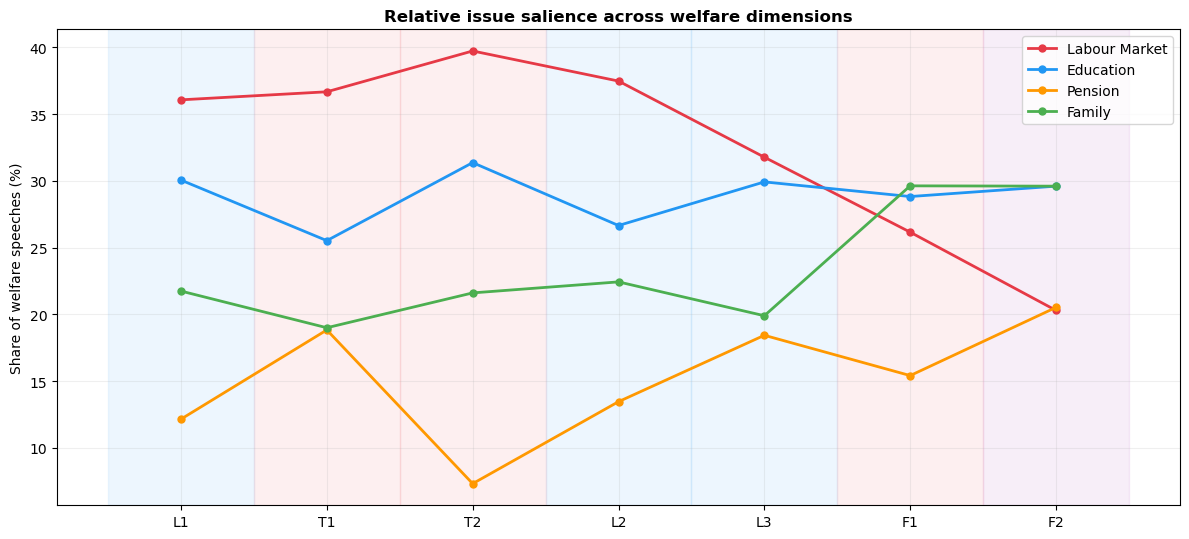

In [112]:
#figure 9: relative issue salience across welfare dimensions

DIM_COLOR_SALIENCE = {
    'labour_market_policy__welfare_retrenchment': '#E63946',
    'education__social_investment':               '#2196F3',
    'pension__fiscal_sustainability':             '#FF9800',
    'family__social_investment':                  '#4CAF50',
}

#speech counts per (government, dimension) across all parties
sal = (
    df_final.groupby(['government', 'dim_key'], observed=True)['n_speeches']
    .sum().reset_index()
)
totals = sal.groupby('government')['n_speeches'].transform('sum')
sal['share'] = sal['n_speeches'] / totals * 100

fig, ax = plt.subplots(figsize=(12, 5.5))

#government period bloc shading
for i, govt in enumerate(GOVERNMENT_ORDER):
    color = GOVT_COLORS_SHADE.get(GOVERNMENT_BLOC.get(govt), 'grey')
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.08, color=color)

x_pos = np.arange(len(GOVERNMENT_ORDER))
x_labels = [GOVT_SHORT[g] for g in GOVERNMENT_ORDER]

for dim_key in DIMENSIONS:
    ys = []
    for govt in GOVERNMENT_ORDER:
        row = sal[(sal['government'] == govt) & (sal['dim_key'] == dim_key)]
        ys.append(row['share'].values[0] if not row.empty else np.nan)
    ax.plot(x_pos, ys, marker='o', linewidth=2, markersize=5,
            color=DIM_COLOR_SALIENCE[dim_key], label=DIM_SHORT[dim_key])

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Share of welfare speeches (%)")
ax.set_title("Relative issue salience across welfare dimensions", fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "salience_relative_shares.png"), dpi=150, bbox_inches='tight')
plt.show()

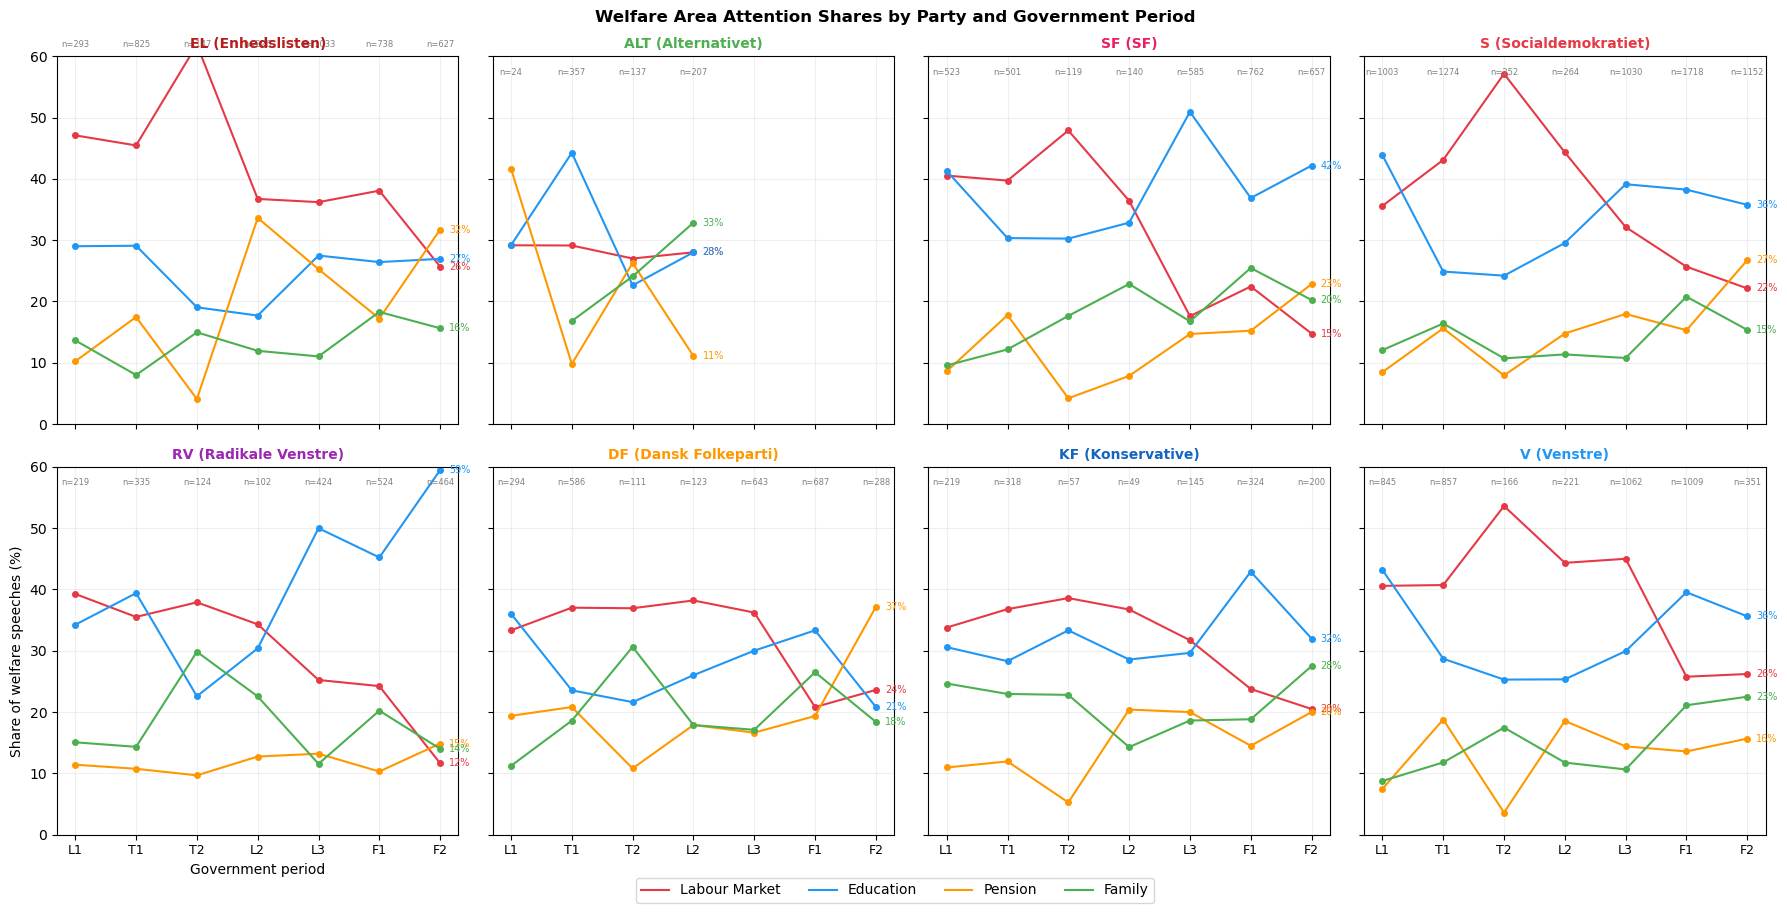

In [ ]:
#figure 10: party-level attention shifts

df_speech_attention = pd.read_csv(
    os.path.join(REPO_ROOT, "pairwise-comparison/output/classified_speeches.csv"),
    low_memory=False,
)
#map raw welfare-area label to canonical dim_key
AREA_TO_DIM = {
    'labour_market_policy': 'labour_market_policy__welfare_retrenchment',
    'education':            'education__social_investment',
    'pension':              'pension__fiscal_sustainability',
    'family':               'family__social_investment',
}
df_attention = df_speech_attention[df_speech_attention['final_llm_label'].isin(AREA_TO_DIM)].copy()
df_attention['dim_key'] = df_attention['final_llm_label'].map(AREA_TO_DIM)
df_attention['government'] = df_attention['year'].map(GOVERNMENT_PERIODS)
df_attention = df_attention.dropna(subset=['party', 'government'])

#share per (party, government, dim)
attention = (
    df_attention.groupby(['party', 'government', 'dim_key']).size()
    .reset_index(name='n')
)
totals = attention.groupby(['party', 'government'])['n'].transform('sum')
attention['share'] = attention['n'] / totals

PARTY_ORDER_PLOT = ['EL', 'ALT', 'SF', 'S', 'RV', 'DF', 'KF', 'V']
DIM_COLOR = {
    'labour_market_policy__welfare_retrenchment': '#E63946',
    'education__social_investment':               '#2196F3',
    'pension__fiscal_sustainability':             '#FF9800',
    'family__social_investment':                  '#4CAF50',
}
DIM_PLOT_LABEL = {
    'labour_market_policy__welfare_retrenchment': 'Labour Market',
    'education__social_investment':               'Education',
    'pension__fiscal_sustainability':             'Pension',
    'family__social_investment':                  'Family',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
for idx, party in enumerate(PARTY_ORDER_PLOT):
    ax = axes[idx // 4, idx % 4]
    party_df = attention[attention['party'] == party]
    govt_data = []
    for govt in GOVERNMENT_ORDER:
        sub = party_df[party_df['government'] == govt]
        if sub.empty:
            continue
        n_total = sub['n'].sum()
        govt_data.append((govt, n_total, dict(zip(sub['dim_key'], sub['share']))))

    if not govt_data:
        ax.set_title(f"{party} ({PARTY_LABELS.get(party, party)}) — no data")
        continue

    x_labels = [GOVT_SHORT[g] for g, _, _ in govt_data]
    x_pos = np.arange(len(x_labels))

    for dim_key in DIMENSIONS:
        ys = [d.get(dim_key, np.nan) * 100 for _, _, d in govt_data]
        color = DIM_COLOR[dim_key]
        ax.plot(x_pos, ys, marker='o', color=color, linewidth=1.5, markersize=4,
                label=DIM_PLOT_LABEL[dim_key])
        last_val = ys[-1]
        if not np.isnan(last_val):
            ax.text(x_pos[-1] + 0.15, last_val, f"{last_val:.0f}%",
                    color=color, fontsize=7, va='center')

    #n annotations at top
    for j, (_, n_total, _) in enumerate(govt_data):
        ax.text(j, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 60,
                f"n={n_total}", ha='center', fontsize=6, color='grey')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_title(f"{party} ({PARTY_LABELS.get(party, party)})",
                 color=PARTY_COLORS.get(party, 'black'), fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.set_ylim(0, 60)

axes[1, 0].set_xlabel("Government period", fontsize=10)
axes[1, 0].set_ylabel("Share of welfare speeches (%)", fontsize=10)

#shared legend
handles = [plt.Line2D([], [], color=DIM_COLOR[dk], label=DIM_PLOT_LABEL[dk]) for dk in DIMENSIONS]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Welfare Area Attention Shares by Party and Government Period",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "attention_shares_by_party.png"),
            dpi=150, bbox_inches='tight')
plt.show()

Preparing salience data...


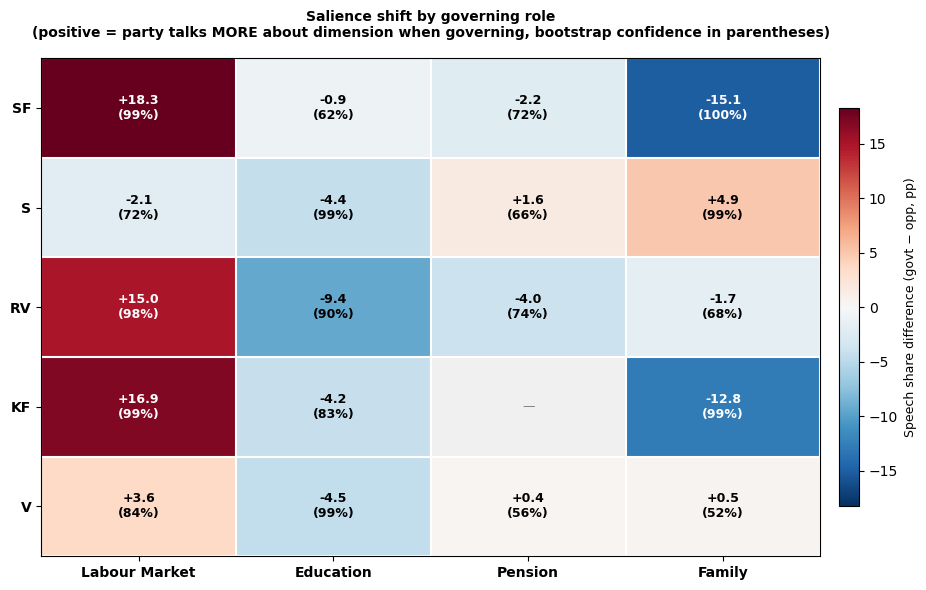


Party  Dimension           Slope (pp/period)        p   Sig
S      Labour Market                   -3.20   0.0035     *
S      Education                       +0.04   0.9486      
S      Pension                         +2.63   0.0116     *
S      Family                          +0.53   0.5032      
EL     Labour Market                   -3.37   0.0254     *
EL     Education                       +0.63   0.6415      
EL     Pension                         +0.87   0.4462      
EL     Family                          +1.87   0.2026      
ALT    Labour Market                   -3.49   0.4239      
ALT    Education                       -7.04   0.2419      
SF     Labour Market                   -3.46   0.0361     *
SF     Education                       -1.58   0.1967      
SF     Pension                         +1.17   0.1692      
SF     Family                          +3.87   0.0268     *
RV     Labour Market                   -4.44   0.1929      
RV     Education                       

In [ ]:
#figure 11: salience by governing role + position interaction

def prepare_salience_data(df_final):
    df = df_final.copy()
    if 'role' not in df.columns:
        df['role'] = df.apply(
            lambda r: assign_role(r['government'], r['party']), axis=1
        )
    total_by_party_year = df.groupby(['party', 'year'])['n_speeches'].sum().reset_index()
    total_by_party_year.rename(columns={'n_speeches': 'total_speeches'}, inplace=True)
    df = df.merge(total_by_party_year, on=['party', 'year'], how='left')
    df['speech_share'] = df['n_speeches'] / df['total_speeches'] * 100
    return df

#figure 12: salience by governing role

def salience_by_role(df, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    results = []
    for party in PARTY_ORDER:
        for dim_key in DIMENSIONS:
            sub = df[(df['party'] == party) & (df['dim_key'] == dim_key)]
            govt_shares = sub[sub['role'] == 'government']['speech_share'].values
            opp_shares = sub[sub['role'] == 'opposition']['speech_share'].values
            if len(govt_shares) < 2 or len(opp_shares) < 2:
                continue
            obs_diff = govt_shares.mean() - opp_shares.mean()
            boot_diffs = np.array([
                rng.choice(govt_shares, size=len(govt_shares), replace=True).mean() -
                rng.choice(opp_shares, size=len(opp_shares), replace=True).mean()
                for _ in range(n_bootstrap)
            ])
            pct = (boot_diffs > 0).mean() * 100 if obs_diff > 0 else (boot_diffs < 0).mean() * 100
            results.append({
                'party': party, 'dim_key': dim_key, 'dimension': DIM_SHORT[dim_key],
                'govt_share': round(govt_shares.mean(), 1),
                'opp_share': round(opp_shares.mean(), 1),
                'diff': round(obs_diff, 1),
                'ci_lo': round(np.percentile(boot_diffs, 2.5), 1),
                'ci_hi': round(np.percentile(boot_diffs, 97.5), 1),
                'significant': (np.percentile(boot_diffs, 2.5) > 0) or (np.percentile(boot_diffs, 97.5) < 0),
                'pct_govt_higher': round(pct, 1),
            })
    return pd.DataFrame(results)

def plot_salience_heatmap(df_role):
    HEATMAP_ORDER = ['SF', 'S', 'RV', 'KF', 'V']
    parties = [p for p in HEATMAP_ORDER if p in df_role['party'].values]

    matrix = np.full((len(parties), len(DIMENSIONS)), np.nan)
    pct_matrix = np.full((len(parties), len(DIMENSIONS)), np.nan)

    for i, party in enumerate(parties):
        for j, dim_key in enumerate(DIMENSIONS):
            row = df_role[(df_role['party'] == party) & (df_role['dim_key'] == dim_key)]
            if not row.empty:
                matrix[i, j] = row.iloc[0]['diff']
                pct_matrix[i, j] = row.iloc[0]['pct_govt_higher']

    vmax = max(np.nanmax(np.abs(matrix)), 1)
    fig, ax = plt.subplots(figsize=(10, 6))
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='#f0f0f0')
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=-vmax, vmax=vmax)

    for i in range(len(parties)):
        for j in range(len(DIMENSIONS)):
            val = matrix[i, j]
            pct = pct_matrix[i, j]
            if np.isnan(val):
                ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='grey')
            else:
                text_color = 'white' if abs(val) > vmax * 0.6 else 'black'
                label = f'{val:+.1f}\n({pct:.0f}%)' if not np.isnan(pct) else f'{val:+.1f}'
                ax.text(j, i, label, ha='center', va='center',
                        fontsize=9, fontweight='bold', color=text_color)

    ax.set_xticks(range(len(DIMENSIONS)))
    ax.set_xticklabels([DIM_SHORT[dk] for dk in DIMENSIONS], fontsize=10, fontweight='bold')
    ax.set_yticks(range(len(parties)))
    ax.set_yticklabels(parties, fontsize=10, fontweight='bold')
    for i in range(len(parties) + 1):
        ax.axhline(i - 0.5, color='white', linewidth=1.5)
    for j in range(len(DIMENSIONS) + 1):
        ax.axvline(j - 0.5, color='white', linewidth=1.5)
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Speech share difference (govt − opp, pp)', fontsize=9)
    ax.set_title('Salience shift by governing role\n'
                 '(positive = party talks MORE about dimension when governing, '
                 'bootstrap confidence in parentheses)',
                 fontsize=10, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, "salience_by_role_heatmap.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

#salience trends: slopes per government period

def salience_trends(df):
    govt_order_map = {g: i for i, g in enumerate(GOVERNMENT_ORDER)}

    #aggregate to government-period level
    govt_shares = df.groupby(['party', 'government', 'dim_key'])['speech_share'].mean().reset_index()
    govt_shares['govt_order'] = govt_shares['government'].map(govt_order_map)

    results = []
    for party in PARTY_ORDER:
        for dim_key in DIMENSIONS:
            sub = govt_shares[
                (govt_shares['party'] == party) & (govt_shares['dim_key'] == dim_key)
            ].sort_values('govt_order')
            if len(sub) < 4:
                continue
            slope, intercept, r, p, se = stats.linregress(sub['govt_order'], sub['speech_share'])
            results.append({
                'party': party, 'dim_key': dim_key, 'dimension': DIM_SHORT[dim_key],
                'slope_pp_per_period': round(slope, 2),
                'p': round(p, 4), 'r': round(r, 3),
                'n_periods': len(sub),
                'significant': p < 0.05,
            })

    df_results = pd.DataFrame(results)

    print(f"\n{'Party':<6} {'Dimension':<18} {'Slope (pp/period)':>18} {'p':>8} {'Sig':>5}")
    for _, row in df_results.iterrows():
        sig_m = "*" if row['significant'] else " "
        print(f"{row['party']:<6} {row['dimension']:<18} "
              f"{row['slope_pp_per_period']:>+18.2f} {row['p']:>8.4f} {sig_m:>5}")
    return df_results

#substitution correlations

def salience_substitution(df):
    results = []
    for party in PARTY_ORDER:
        p_data = df[df['party'] == party]
        share_matrix = p_data.pivot_table(index='year', columns='dim_key', values='speech_share')
        dims_available = [d for d in DIMENSIONS if d in share_matrix.columns]
        if len(dims_available) < 2:
            continue
        for i, dim_a in enumerate(dims_available):
            for dim_b in dims_available[i+1:]:
                valid = share_matrix[[dim_a, dim_b]].dropna()
                if len(valid) < 5:
                    continue
                r, p = stats.pearsonr(valid[dim_a], valid[dim_b])
                results.append({
                    'party': party,
                    'dim_a': DIM_SHORT[dim_a], 'dim_b': DIM_SHORT[dim_b],
                    'r': round(r, 3), 'p': round(p, 4),
                    'n': len(valid), 'significant': p < 0.05,
                })

    df_results = pd.DataFrame(results)

    sig = df_results[df_results['significant']]
    for _, row in sig.iterrows():
        pattern = "Substitution" if row['r'] < 0 else "Co-movement"
        print(f"  {row['party']:<6} {row['dim_a']:<18} ↔ {row['dim_b']:<18} "
              f"r={row['r']:+.3f} ({pattern})")
    return df_results

#score change vs share change

def salience_position_interaction(df):
    df_valid = df[
        df['reliability_simple'].isin(RELIABILITY_KEEP) &
        df['cell_reliable']
    ].copy()
    df_sorted = df_valid.sort_values(['party', 'dim_key', 'year'])

    change_records = []
    for (party, dim_key), group in df_sorted.groupby(['party', 'dim_key']):
        group = group.sort_values('year')
        for i in range(1, len(group)):
            if group.iloc[i]['year'] != group.iloc[i-1]['year'] + 1:
                continue
            change_records.append({
                'party': party, 'dim_key': dim_key,
                'score_change': abs(group.iloc[i]['mean_score'] - group.iloc[i-1]['mean_score']),
                'share_change': group.iloc[i]['speech_share'] - group.iloc[i-1]['speech_share'],
            })

    df_changes = pd.DataFrame(change_records)

    print(f"\n{'Party':<6} {'r':>7} {'p':>8} {'N':>5}")
    for party in PARTY_ORDER:
        p_data = df_changes[df_changes['party'] == party]
        if len(p_data) < 5:
            continue
        r, p = stats.pearsonr(p_data['score_change'], p_data['share_change'])
        sig_m = "*" if p < 0.05 else " "
        print(f"  {party:<6} {r:>+7.3f} {p:>8.4f} {len(p_data):>5}{sig_m}")

    return df_changes

#run

df_salience = prepare_salience_data(df_final)
df_role_salience = salience_by_role(df_salience)
plot_salience_heatmap(df_role_salience)
salience_trends(df_salience)
salience_substitution(df_salience)
salience_position_interaction(df_salience)

## robustness checks

### speaker dominance

In [115]:
#speaker dominance

df_speech = pd.read_csv(os.path.join(TIES_DIR, "simple_bootstrap_speech_level.csv"))

#per cell: total speeches + max share by single speaker
dom = (
    df_speech
    .groupby(["dim_key", "party", "year", "speaker"], observed=True)
    .size()
    .reset_index(name="n_by_speaker")
)
cell_totals = (
    dom.groupby(["dim_key", "party", "year"], observed=True)["n_by_speaker"]
    .agg(n_total="sum", n_top_speaker="max", n_speakers="count")
    .reset_index()
)
cell_totals["max_share"] = cell_totals["n_top_speaker"] / cell_totals["n_total"]

#filter to cells that survive into the analysis (n>=MIN_SPEECHES, party not excluded)
PARTY_EXCLUSIONS_FLAT = {dk: set(parties) for dk, parties in PARTY_EXCLUSIONS.items()}
mask = pd.Series(True, index=cell_totals.index)
for dk in DIMENSIONS:
    excluded = PARTY_EXCLUSIONS_FLAT.get(dk, set())
    mask &= ~((cell_totals["dim_key"] == dk) & (cell_totals["party"].isin(excluded)))
cell_totals = cell_totals[mask & (cell_totals["n_total"] >= MIN_SPEECHES)].copy()

print("speaker dominance per dimension")
print(f"{'dimension':<48} {'cells':>6} {'mean max share':>16} {'>50%':>7} {'>75%':>7}")
for dim_key in DIMENSIONS:
    d = cell_totals[cell_totals["dim_key"] == dim_key]
    if len(d) == 0:
        continue
    n = len(d)
    mean_share = d["max_share"].mean()
    pct_over_50 = 100 * (d["max_share"] > 0.5).mean()
    pct_over_75 = 100 * (d["max_share"] > 0.75).mean()
    print(f"{DIM_LABELS[dim_key]:<48} {n:>6} {mean_share:>15.2f}  {pct_over_50:>6.1f}% {pct_over_75:>6.1f}%")

#extreme dominance check: are >0.75 cells thin?
extreme = cell_totals[cell_totals["max_share"] > 0.75]
print(f"\nextreme dominance (>0.75): {len(extreme)} cells, median n_speakers = {extreme['n_speakers'].median():.0f}, median n_total = {extreme['n_total'].median():.0f}")

#leave-top-speaker-out sensitivity: mean bt score shift per cell vs original.

mean_shifts = []
for dim_key in DIMENSIONS:
    d = df_speech[df_speech["dim_key"] == dim_key].copy()
    if len(d) == 0:
        continue
    #count per (party, year, speaker)
    speech_counts = (
        d.groupby(["party", "year", "speaker"], observed=True)
        .size()
        .reset_index(name="n")
    )
    #identify top speaker per (party, year)
    top_speaker = (
        speech_counts.sort_values("n", ascending=False)
        .drop_duplicates(["party", "year"])
        [["party", "year", "speaker"]]
        .rename(columns={"speaker": "top_speaker"})
    )
    d = d.merge(top_speaker, on=["party", "year"], how="left")

    #means per (party, year)
    orig = d.groupby(["party", "year"])["bt_score"].mean().rename("orig")
    drop = (
        d[d["speaker"] != d["top_speaker"]]
        .groupby(["party", "year"])["bt_score"].mean()
        .rename("drop_top")
    )
    compare = pd.concat([orig, drop], axis=1).dropna()
    compare["diff"] = (compare["orig"] - compare["drop_top"]).abs()
    mean_shifts.append({
        "dimension": DIM_LABELS[dim_key],
        "n_cells_compared": len(compare),
        "mean_abs_shift": compare["diff"].mean(),
        "max_abs_shift": compare["diff"].max(),
    })

shifts_df = pd.DataFrame(mean_shifts)
print("leave-top-speaker-out sensitivity")
print(shifts_df.to_string(index=False))

speaker dominance per dimension
dimension                                         cells   mean max share    >50%    >75%
Labour Market: Welfare Retrenchment                 114            0.33    11.4%    1.8%
Education: Social Investment                        119            0.24     1.7%    0.0%
Pension: Fiscal Sustainability                       77            0.31     9.1%    0.0%
Family: Social Investment                           121            0.31     6.6%    0.0%

extreme dominance (>0.75): 2 cells, median n_speakers = 1, median n_total = 5
leave-top-speaker-out sensitivity
                          dimension  n_cells_compared  mean_abs_shift  max_abs_shift
Labour Market: Welfare Retrenchment               140        0.174882       1.688549
       Education: Social Investment               144        0.195871       1.022590
     Pension: Fiscal Sustainability               123        0.258017       1.503203
          Family: Social Investment               137        0.179107 

### speaker-level repositioning

In [ ]:
#speaker-level repositioning

df_speakers = pd.read_csv(
    os.path.join(TIES_DIR, "simple_bootstrap_speaker_year.csv")
)

print(f"Speaker-year observations: {len(df_speakers)}")
print(f"Unique speakers: {df_speakers['speaker'].nunique()}")
print(f"Columns: {list(df_speakers.columns)}")
def analyze_speaker_trends(df_speakers, df_slopes_abs, min_years=3):
    #get significant party-dimensions
    sig = df_slopes_abs[df_slopes_abs['ci_excludes_zero']].copy()
    
    all_results = []
    party_summaries = []
    
    for _, sig_row in sig.iterrows():
        party = sig_row['party']
        dim_key = sig_row['dim_key']
        party_slope = sig_row['slope']
        party_direction = 'positive' if party_slope > 0 else 'negative'
        
        #filter to this party-dimension
        df = df_speakers[
            (df_speakers['party'] == party) &
            (df_speakers['dim_key'] == dim_key)
        ].copy()
        
        #only speakers with enough years
        speaker_years = df.groupby('speaker')['year'].nunique()
        valid_speakers = speaker_years[speaker_years >= min_years].index
        df = df[df['speaker'].isin(valid_speakers)]
        
        if len(valid_speakers) == 0:
            continue
        
        print(f"{party} — {DIM_LABELS.get(dim_key, dim_key)}")
        print(f"Party slope: {party_slope:+.4f} ({'toward pole B' if party_slope > 0 else 'toward pole A'})")
        print(f"Speakers with >={min_years} years: {len(valid_speakers)}")
        print(f"{'='*70}")
        
        speaker_results = []
        
        for speaker in sorted(valid_speakers):
            sp_df = df[df['speaker'] == speaker].sort_values('year')
            years = sp_df['year'].values
            scores = sp_df['mean_score'].values
            n_years = len(years)
            
            if n_years < min_years:
                continue
            
            slope, intercept, r, p, se = stats.linregress(years, scores)
            same_direction = (slope > 0) == (party_slope > 0)
            
            #early vs late comparison
            mid_year = (years.min() + years.max()) / 2
            early_scores = scores[years <= mid_year]
            late_scores = scores[years > mid_year]
            early_mean = np.mean(early_scores) if len(early_scores) > 0 else np.nan
            late_mean = np.mean(late_scores) if len(late_scores) > 0 else np.nan
            
            speaker_results.append({
                'dim_key':        dim_key,
                'party':          party,
                'speaker':        speaker,
                'n_years':        n_years,
                'year_range':     f"{years.min()}-{years.max()}",
                'slope':          round(slope, 5),
                'r':              round(r, 3),
                'p_value':        round(p, 4),
                'same_direction': same_direction,
                'early_mean':     round(early_mean, 4),
                'late_mean':      round(late_mean, 4),
                'shift':          round(late_mean - early_mean, 4) if not np.isnan(early_mean) and not np.isnan(late_mean) else np.nan,
                'mean_score':     round(np.mean(scores), 4),
                'n_speeches':     int(sp_df['n_speeches'].sum()),
            })
        
        df_sp = pd.DataFrame(speaker_results)
        all_results.append(df_sp)
        
        #summary statistics
        n_same = df_sp['same_direction'].sum()
        n_total = len(df_sp)
        pct_same = (n_same / n_total * 100) if n_total > 0 else 0
        
        #weighted by number of speeches
        total_speeches = df_sp['n_speeches'].sum()
        weighted_same = df_sp[df_sp['same_direction']]['n_speeches'].sum()
        pct_same_weighted = (weighted_same / total_speeches * 100) if total_speeches > 0 else 0
        
        median_slope = df_sp['slope'].median()
        mean_slope = df_sp['slope'].mean()
        
        party_summaries.append({
            'party':              party,
            'dim_key':            dim_key,
            'dimension':          DIM_LABELS.get(dim_key, dim_key),
            'party_slope':        party_slope,
            'n_speakers':         n_total,
            'n_same_direction':   n_same,
            'pct_same_direction': round(pct_same, 1),
            'pct_same_weighted':  round(pct_same_weighted, 1),
            'median_speaker_slope': round(median_slope, 5),
            'mean_speaker_slope':   round(mean_slope, 5),
        })
        
        #display
        print(f"\n  {pct_same:.0f}% of speakers ({n_same}/{n_total}) move in same direction as party")
        print(f"  Weighted by speeches: {pct_same_weighted:.0f}%")
        print(f"  Median speaker slope: {median_slope:+.4f} (party: {party_slope:+.4f})")
        
        print(f"\n  {'Speaker':<30} {'Years':>6} {'Slope':>8} {'Same?':>6} {'Early':>8} {'Late':>8} {'Shift':>8} {'Speeches':>9}")
        print("  " + "-" * 95)
        
        for _, row in df_sp.sort_values('slope', ascending=False).iterrows():
            marker = "✓" if row['same_direction'] else "✗"
            print(f"  {row['speaker']:<30} {row['n_years']:>6} {row['slope']:>+8.4f} {marker:>6} "
                  f"{row['early_mean']:>8.3f} {row['late_mean']:>8.3f} {row['shift']:>+8.3f} {row['n_speeches']:>9}")
    
    df_all = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    df_summary = pd.DataFrame(party_summaries)
    
    #save
    df_all.to_csv(os.path.join(ANALYSIS_DIR, "speaker_trends_detail.csv"), index=False)
    df_summary.to_csv(os.path.join(ANALYSIS_DIR, "speaker_trends_summary.csv"), index=False)
    
    return df_all, df_summary

df_speaker_trends, df_speaker_summary = analyze_speaker_trends(df_speakers, df_slopes_abs)

print(f"\n{'Party':<6} {'Dimension':<42} {'Party slope':>11} {'Speakers':>9} "
      f"{'% same dir':>10} {'% weighted':>10} {'Median sp.':>10}")

for _, row in df_speaker_summary.iterrows():
    verdict = "COLLECTIVE" if row['pct_same_direction'] >= 60 else "MIXED" if row['pct_same_direction'] >= 40 else "INDIVIDUAL"
    print(f"{row['party']:<6} {row['dimension']:<42} {row['party_slope']:>+10.4f} "
          f"{row['n_speakers']:>9} {row['pct_same_direction']:>9.0f}% "
          f"{row['pct_same_weighted']:>9.0f}% {row['median_speaker_slope']:>+10.4f}  → {verdict}")
#focus on S Labour Market and EL Education as the key cases
df_speakers = pd.read_csv(
    os.path.join(TIES_DIR, "simple_bootstrap_speaker_year.csv")
)

#apply party exclusions
frames = []
for dim_key in DIMENSIONS:
    excluded = PARTY_EXCLUSIONS.get(dim_key, [])
    dim_df = df_speakers[
        (df_speakers['dim_key'] == dim_key) &
        (~df_speakers['party'].isin(excluded))
    ]
    frames.append(dim_df)

df_all = pd.concat(frames, ignore_index=True)

MIN_YEARS = 3 

results = []

for dim_key in DIMENSIONS:
    dim_df = df_all[df_all['dim_key'] == dim_key]
    parties = dim_df['party'].unique()
    
    for party in sorted(parties):
        party_df = dim_df[dim_df['party'] == party]
        
        #party-level slope (across all speakers)
        party_year_means = party_df.groupby('year')['mean_score'].mean().reset_index()
        if len(party_year_means) < 3:
            continue
        party_slope, _, _, _, _ = stats.linregress(
            party_year_means['year'], party_year_means['mean_score']
        )
        
        #individual speaker slopes
        speaker_years = party_df.groupby('speaker')['year'].nunique()
        valid_speakers = speaker_years[speaker_years >= MIN_YEARS].index
        speaker_df = party_df[party_df['speaker'].isin(valid_speakers)]
        
        if len(valid_speakers) == 0:
            continue
        
        n_same = 0
        n_total = 0
        speeches_same = 0
        speeches_total = 0
        speaker_slopes = []
        
        for speaker in valid_speakers:
            sp = speaker_df[speaker_df['speaker'] == speaker].sort_values('year')
            if len(sp) < MIN_YEARS:
                continue
            
            slope, _, _, _, _ = stats.linregress(sp['year'], sp['mean_score'])
            same_direction = (slope > 0) == (party_slope > 0)
            n_speeches = sp['n_speeches'].sum()
            
            n_total += 1
            speeches_total += n_speeches
            if same_direction:
                n_same += 1
                speeches_same += n_speeches
            speaker_slopes.append(slope)
        
        if n_total == 0:
            continue
        
        pct_same = round(n_same / n_total * 100, 1)
        pct_weighted = round(speeches_same / speeches_total * 100, 1) if speeches_total > 0 else 0
        median_slope = round(np.median(speaker_slopes), 4)
        
        #classification
        if pct_weighted >= 65:
            classification = "Collective"
        elif pct_weighted >= 50:
            classification = "Mixed"
        else:
            classification = "Individual"
        
        results.append({
            'party': party,
            'dim_key': dim_key,
            'dimension': DIM_LABELS[dim_key],
            'party_slope': round(party_slope, 4),
            'n_speakers': n_total,
            'pct_same_direction': pct_same,
            'pct_weighted': pct_weighted,
            'median_speaker_slope': median_slope,
            'classification': classification,
        })

df_results = pd.DataFrame(results)

agg = df_results.groupby('party').agg(
    dimensions_covered=('dim_key', 'nunique'),
    avg_pct_same_direction=('pct_same_direction', 'mean'),
    avg_pct_weighted=('pct_weighted', 'mean'),
    total_speakers=('n_speakers', 'sum'),
).reset_index()

agg['avg_pct_same_direction'] = agg['avg_pct_same_direction'].round(1)
agg['avg_pct_weighted'] = agg['avg_pct_weighted'].round(1)

#classification based on average weighted agreement
agg['classification'] = agg['avg_pct_weighted'].apply(
    lambda x: 'Collective' if x >= 65 else ('Mixed' if x >= 50 else 'Individual')
)

#sort by classification then party
sort_order = {'Collective': 0, 'Mixed': 1, 'Individual': 2}
agg['sort'] = agg['classification'].map(sort_order)
agg = agg.sort_values(['sort', 'party']).drop(columns='sort')

#sort: collective first, then mixed, then individual
df_results['sort'] = df_results['classification'].map(sort_order)
df_results = df_results.sort_values(['sort', 'party', 'dim_key']).drop(columns='sort')

print(f"\n{'Party':<6} {'Dimension':<40} {'Party slope':>11} {'Speakers':>9} "
      f"{'% same':>7} {'% weighted':>10} {'Med. slope':>10} {'Class.':>12}")

for _, row in df_results.iterrows():
    print(f"{row['party']:<6} {row['dimension']:<40} {row['party_slope']:>+10.4f} "
          f"{row['n_speakers']:>9} {row['pct_same_direction']:>6.0f}% "
          f"{row['pct_weighted']:>9.0f}% {row['median_speaker_slope']:>+10.4f} "
          f"{row['classification']:>12}")

print("TABLE 2: AGGREGATED SPEAKER AGREEMENT PER PARTY (ACROSS DIMENSIONS)")

print(f"\n{'Party':<6} {'Dimensions':>10} {'Avg % same':>10} {'Avg % weighted':>14} "
      f"{'Total speakers':>14} {'Classification':>14}")

for _, row in agg.iterrows():
    print(f"{row['party']:<6} {row['dimensions_covered']:>10} "
          f"{row['avg_pct_same_direction']:>9.0f}% {row['avg_pct_weighted']:>13.0f}% "
          f"{row['total_speakers']:>14} {row['classification']:>14}")
#save
df_results.to_csv(os.path.join(ANALYSIS_DIR, "appendix_speaker_trends_all.csv"), index=False)
agg.to_csv(os.path.join(ANALYSIS_DIR, "appendix_speaker_trends_aggregated.csv"), index=False)

print(f"\nSaved to {ANALYSIS_DIR}")

Speaker-year observations: 3404
Unique speakers: 373
Columns: ['dim_key', 'speaker', 'party', 'year', 'government', 'mean_score', 'n_speeches', 'ci_lower_simple', 'ci_upper_simple', 'ci_width_simple']
DF — Education: Social Investment
Party slope: +0.0621 (toward pole B)
Speakers with >=3 years: 12

  58% of speakers (7/12) move in same direction as party
  Weighted by speeches: 51%
  Median speaker slope: +0.0093 (party: +0.0621)

  Speaker                         Years    Slope  Same?    Early     Late    Shift  Speeches
  -----------------------------------------------------------------------------------------------
  Marlene Harpsøe                     6  +0.1529      ✓   -0.538    0.765   +1.303        12
  Mette Hjermind Dencker              3  +0.0837      ✓   -0.888   -0.211   +0.677         6
  Alex Ahrendtsen                    14  +0.0812      ✓   -0.421    0.434   +0.854        19
  Martin Henriksen                    4  +0.0436      ✓    0.807    1.210   +0.403         5
 

### inter-party responsiveness

In [ ]:
#inter-party responsiveness

def analyze_party_responsiveness(df_analysis, max_lag=2):
    df_reliable = df_analysis[
        df_analysis['reliability_simple'].isin(RELIABILITY_KEEP) &
        df_analysis['cell_reliable']
    ].copy()
    
    results = []
    
    for dim_key in DIMENSIONS:
        dim_df = df_reliable[df_reliable['dim_key'] == dim_key]
        parties = sorted(dim_df['party'].unique())
        
        #build party-year score matrix
        score_matrix = dim_df.pivot_table(
            index='year', columns='party', values='mean_score'
        )
        
        #test each pair with each lag
        for lag in range(0, max_lag + 1):
            for leader in parties:
                for follower in parties:
                    if leader == follower:
                        continue
                    
                    if leader not in score_matrix.columns or follower not in score_matrix.columns:
                        continue
                    
                    #leader at time t, follower at time t+lag
                    leader_scores = score_matrix[leader]
                    follower_scores = score_matrix[follower].shift(-lag)
                    
                    #drop NAs
                    valid = pd.DataFrame({
                        'leader': leader_scores,
                        'follower': follower_scores
                    }).dropna()
                    
                    if len(valid) < 5:
                        continue
                    
                    r, p = stats.pearsonr(valid['leader'], valid['follower'])
                    
                    results.append({
                        'dim_key': dim_key,
                        'dimension': DIM_LABELS.get(dim_key, dim_key),
                        'leader': leader,
                        'leader_bloc': PARTY_BLOCS.get(leader),
                        'follower': follower,
                        'follower_bloc': PARTY_BLOCS.get(follower),
                        'lag': lag,
                        'same_bloc': PARTY_BLOCS.get(leader) == PARTY_BLOCS.get(follower),
                        'r': round(r, 3),
                        'p': round(p, 4),
                        'significant': p < 0.05,
                        'n_years': len(valid),
                    })
    
    df_results = pd.DataFrame(results)
    df_results.to_csv(
        os.path.join(ANALYSIS_DIR, "party_responsiveness.csv"), index=False
    )
    
    return df_results

def summarize_responsiveness(df_resp):
    print("Does party B's score at t+lag correlate with party A's score at t?")
    
    #theoretical pairs
    
    theoretical_pairs = [
        #S responding to right-bloc parties
        ('DF', 'S', 'Does S follow DF? (welfare chauvinism pressure)'),
        ('V', 'S', 'Does S follow V? (centripetal convergence)'),
        ('KF', 'S', 'Does S follow KF?'),
        
        #S responding to left-bloc parties
        ('EL', 'S', 'Does S follow EL? (left anchor)'),
        ('SF', 'S', 'Does S follow SF?'),
        
        #Left parties responding to S
        ('S', 'EL', 'Does EL respond to S? (niche party test)'),
        ('S', 'SF', 'Does SF respond to S?'),
        
        #Right parties responding to each other
        ('V', 'KF', 'Does KF follow V?'),
        ('DF', 'V', 'Does V follow DF?'),
        
        #Cross-bloc responses
        ('S', 'V', 'Does V respond to S?'),
        ('S', 'DF', 'Does DF respond to S?'),
    ]
    
    print("\n--- KEY THEORETICAL PAIRS ---\n")
    
    for leader, follower, question in theoretical_pairs:
        print(f"\n{question}")
        pair_df = df_resp[
            (df_resp['leader'] == leader) &
            (df_resp['follower'] == follower)
        ].sort_values(['dim_key', 'lag'])
        
        if len(pair_df) == 0:
            print("  No data")
            continue
        
        for _, row in pair_df.iterrows():
            sig_marker = "*" if row['significant'] else " "
            dim_short = row['dimension'][:30]
            print(f"  {dim_short:<32} lag={row['lag']}  r={row['r']:>+6.3f}  "
                  f"p={row['p']:.4f}{sig_marker}  n={row['n_years']}")
    
    #within vs cross bloc
    
    print("\n\n--- WITHIN-BLOC vs CROSS-BLOC RESPONSIVENESS ---\n")
    
    for lag in range(0, 3):
        lag_df = df_resp[df_resp['lag'] == lag]
        
        within = lag_df[lag_df['same_bloc']]
        cross = lag_df[~lag_df['same_bloc']]
        
        within_mean_r = within['r'].abs().mean() if len(within) > 0 else np.nan
        cross_mean_r = cross['r'].abs().mean() if len(cross) > 0 else np.nan
        within_pct_sig = (within['significant'].mean() * 100) if len(within) > 0 else 0
        cross_pct_sig = (cross['significant'].mean() * 100) if len(cross) > 0 else 0
        
        print(f"Lag {lag}:")
        print(f"  Within-bloc:  mean |r|={within_mean_r:.3f}, {within_pct_sig:.0f}% significant (n={len(within)})")
        print(f"  Cross-bloc:   mean |r|={cross_mean_r:.3f}, {cross_pct_sig:.0f}% significant (n={len(cross)})")
    
    #lagg correlations
    
    print("\n\n--- STRONGEST LAGGED CORRELATIONS (lag=1, p<0.10) ---\n")
    
    lag1 = df_resp[
        (df_resp['lag'] == 1) &
        (df_resp['p'] < 0.10)
    ].sort_values('p')
    
    if len(lag1) > 0:
        print(f"{'Leader':<6} → {'Follower':<8} {'Dimension':<32} {'r':>6} {'p':>8} {'Bloc':>12}")
        for _, row in lag1.iterrows():
            bloc_rel = "within" if row['same_bloc'] else "cross"
            print(f"{row['leader']:<6} → {row['follower']:<8} {row['dimension'][:30]:<32} "
                  f"{row['r']:>+6.3f} {row['p']:>8.4f} {bloc_rel:>12}")
    else:
        print("  None at p<0.10")
    
    #who s response to
    
    print("\n\n--- S-SPECIFIC: WHO DOES S RESPOND TO? (lag=1) ---\n")
    
    s_follower = df_resp[
        (df_resp['follower'] == 'S') &
        (df_resp['lag'] == 1)
    ].sort_values(['dim_key', 'p'])
    
    if len(s_follower) > 0:
        for dim_key in DIMENSIONS:
            dim_df = s_follower[s_follower['dim_key'] == dim_key]
            if len(dim_df) == 0:
                continue
            print(f"  {DIM_LABELS.get(dim_key, dim_key)}:")
            for _, row in dim_df.iterrows():
                sig_marker = "*" if row['significant'] else " "
                print(f"    {row['leader']:<6} → S   r={row['r']:>+6.3f}  p={row['p']:.4f}{sig_marker}")
    
    return df_resp
df_responsiveness = analyze_party_responsiveness(df_final, max_lag=2)
df_responsiveness = summarize_responsiveness(df_responsiveness)

Does party B's score at t+lag correlate with party A's score at t?

--- KEY THEORETICAL PAIRS ---


Does S follow DF? (welfare chauvinism pressure)
  Education: Social Investment     lag=0  r=+0.378  p=0.2252   n=12
  Education: Social Investment     lag=1  r=+0.156  p=0.6282   n=12
  Education: Social Investment     lag=2  r=-0.279  p=0.3799   n=12
  Family: Social Investment        lag=0  r=+0.019  p=0.9474   n=14
  Family: Social Investment        lag=1  r=-0.132  p=0.6520   n=14
  Family: Social Investment        lag=2  r=-0.032  p=0.9167   n=13
  Labour Market: Welfare Retrenc   lag=0  r=-0.189  p=0.5366   n=13
  Labour Market: Welfare Retrenc   lag=1  r=+0.512  p=0.0737   n=13
  Labour Market: Welfare Retrenc   lag=2  r=+0.003  p=0.9925   n=13
  Pension: Fiscal Sustainability   lag=0  r=-0.375  p=0.2292   n=12
  Pension: Fiscal Sustainability   lag=1  r=+0.068  p=0.8526   n=10
  Pension: Fiscal Sustainability   lag=2  r=-0.658  p=0.0539   n=9

Does S follow V? (centripetal conver

### election year effects

In [118]:
#election year effects

ELECTION_YEARS = [2011, 2015, 2019, 2022]

def classify_year(year):
    for ey in ELECTION_YEARS:
        if year == ey - 1:
            return "pre"
        if year == ey:
            return "election"
        if year == ey + 1:
            return "post"
    return "other"

df_py = df_simple_boot.copy()
df_py["phase"] = df_py["year"].apply(classify_year)
df_py = df_py[df_py["phase"] != "other"]

#filter out excluded parties + apply n>=MIN_SPEECHES
for dk, excl in PARTY_EXCLUSIONS.items():
    df_py = df_py[~((df_py["dim_key"] == dk) & (df_py["party"].isin(excl)))]
df_py = df_py[df_py["n_speeches"] >= MIN_SPEECHES]

#per (dim, party): mean score per phase
phase_means = (
    df_py.groupby(["dim_key", "party", "phase"], observed=True)["mean_score"]
    .mean()
    .unstack("phase")
)

#pre->election and election->post changes
phase_means["pre_to_elec"] = phase_means.get("election") - phase_means.get("pre")
phase_means["elec_to_post"] = phase_means.get("post") - phase_means.get("election")

print("election year score changes")
print(f"{'dim':<45} {'party':<6} {'pre':>7} {'elec':>7} {'post':>7} {'preΔ':>7} {'postΔ':>7}")
for (dim_key, party), row in phase_means.iterrows():
    pre = row.get("pre", float("nan"))
    elec = row.get("election", float("nan"))
    post = row.get("post", float("nan"))
    pre_d = row.get("pre_to_elec", float("nan"))
    post_d = row.get("elec_to_post", float("nan"))
    print(f"{DIM_LABELS[dim_key]:<45} {party:<6} {pre:>+7.2f} {elec:>+7.2f} {post:>+7.2f} {pre_d:>+7.2f} {post_d:>+7.2f}")

#test if pre->election shifts are systematic (sign-consistent per dimension)
print("\nelection year shift summary per dimension")
print(f"{'dim':<45} {'n':>4} {'mean preΔ':>10} {'mean postΔ':>11} {'frac same sign':>16}")
for dim_key in DIMENSIONS:
    sub = phase_means.loc[dim_key].dropna(subset=["pre_to_elec", "elec_to_post"], how="all")
    n = len(sub)
    pre_mean = sub["pre_to_elec"].mean()
    post_mean = sub["elec_to_post"].mean()
    #consistent direction = both pre->elec and elec->post move the same way for a party
    same = ((sub["pre_to_elec"] > 0) == (sub["elec_to_post"] > 0)).mean()
    print(f"{DIM_LABELS[dim_key]:<45} {n:>4} {pre_mean:>+10.3f} {post_mean:>+11.3f} {same:>15.0%}")

#bootstrap mean pre->elec shift per dimension, 1000 iter.

N_BOOT = 1000
rng = np.random.default_rng(SEED)

print("bootstrap of mean pre->election shift per dimension")
print(f"{'dim':<45} {'mean':>8} {'95% ci':>20} {'bootstrap %':>12}")
for dim_key in DIMENSIONS:
    shifts = phase_means.loc[dim_key, "pre_to_elec"].dropna().values
    if len(shifts) == 0:
        continue
    boots = np.array([
        shifts[rng.integers(0, len(shifts), size=len(shifts))].mean()
        for _ in range(N_BOOT)
    ])
    ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
    direction_pct = 100 * (boots > 0).mean() if shifts.mean() > 0 else 100 * (boots < 0).mean()
    print(f"{DIM_LABELS[dim_key]:<45} {shifts.mean():>+8.3f} [{ci_lo:>+5.2f}, {ci_hi:>+5.2f}]    {direction_pct:>10.1f}%")

election year score changes
dim                                           party      pre    elec    post    preΔ   postΔ
Education: Social Investment                  ALT      -0.62   -0.27   +0.15   +0.35   +0.43
Education: Social Investment                  DF       +0.12   +0.08   +0.43   -0.04   +0.35
Education: Social Investment                  EL       -0.45   -0.45   -0.36   -0.00   +0.09
Education: Social Investment                  KF       +0.40   +0.04   +0.40   -0.37   +0.36
Education: Social Investment                  RV       -0.20   +0.37   +0.18   +0.57   -0.19
Education: Social Investment                  S        -0.20   -0.12   +0.09   +0.08   +0.20
Education: Social Investment                  SF       -0.04   -0.43   -0.19   -0.39   +0.24
Education: Social Investment                  V        +0.52   +0.18   +0.43   -0.34   +0.24
Family: Social Investment                     ALT      -0.46   -0.50   +0.02   -0.04   +0.53
Family: Social Investment                 